This is the Jupyter Notebook for the Data analysis and implementation for Fatigue Life Prediction of polymer matrix composites using a Physics informed neural network 

*A physics-informed neural network based on the self-heating effect for fatigue life prediction of polymer matrix composites*

In [2]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 
from sklearn.neighbors import KernelDensity
from scipy.stats import beta
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, root_mean_squared_error
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from xgboost import XGBRegressor
from sklearn.svm import SVR
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error
import torch 
import torch.optim as optim 
import torch.nn as nn 

With the increasing use of polymer matrix composites (PMCs) across different engineering applications, there is more focus on their durability under cyclic loading conditions. Consequently, large efforts have been made for accurate and reliable fatigue life models that encompass the complexity of composite materials within a short time frame. This investigation employs a physics-informed neural network (PINN) with the self-heating behavior of PMCs embedded as soft physics constraints to predict fatigue life of different PMCs reported in literature. This model is applied to different PMCs loaded under cyclic loading conditions and results show that fatigue life can be predicted using load levels and stabilized surface temperature with reasonable accuracy even for PMCs that exhibit scatter.

We are working with the data from the Jia paper, "A new method for determination of fatigue limit of composite laminates based on the thermographic data" 

We collected, Temp vs stress and stress vs Number of cycles data. 
The idea is to build a simple PINN model to facilitate fatigue life predictions with physics loss terms i.e stress monotononicity and temp monotonicity 

In [3]:
np.random.seed(42)

The pipeline is divided into modules. The first part deals with the stress vs temp dataset, and the second part deals with the stress, temp vs number of cycles i.e the implementation of PINN. The pipeline is structured in the following way:
1.  The first module involves developing a regression model to evaluate the self-heating temperatures of Polymer Matrix Composites, which are required as an input for the subsequent fatigue-life prediction from the given stress values.
2. Module 2 consists of augmenting fatigue life data. For this purpose, the original dataset is split into training and testing sets based on the k-fold cross-validation technique. The data available for training are then augmented using Basquin curve fitting and the MCS approach.
3.  In Module 3 the trained XG-Boost model is used to predict the stabilized surface temperature for the corresponding augmented stress level, which is then used as a combined input data/feature map to predict fatigue lives at load levels above the fatigue strength of PMCs. Subsequently, a PINN model, which uses both physics-based and data-driven loss functions for evaluation, is then trained to predict the fatigue life of PMCs.

Importing Temperature vs Stress data. We will first start by checking and importing data collected through real experiments and see how it is.

In [ ]:
file = r"TempvsStress.xlsx"

df_one = pd.read_excel(file)
df_one.to_csv("StressvsNumberofcycles.csv", index=False)

In [5]:
df_one

,Stabilised Temperature(degree C),Maximum Stress(%UTS),Material
0,0.428,29.748,Q1 CRPF Laminates
1,0.917,34.847,Q1 CRPF Laminates
2,1.327,39.724,Q1 CRPF Laminates
3,1.786,45.118,Q1 CRPF Laminates
4,2.422,49.556,Q1 CRPF Laminates
5,2.715,52.586,Q1 CRPF Laminates
6,2.960,54.804,Q1 CRPF Laminates
7,3.479,57.247,Q1 CRPF Laminates
8,3.488,59.978,Q1 CRPF Laminates
9,3.644,62.415,Q1 CRPF Laminates


In [6]:
df_one = df_one.drop([20,21,22,23,24,25,26,27,28,29,30,31])
df_one

,Stabilised Temperature(degree C),Maximum Stress(%UTS),Material
0,0.428,29.748,Q1 CRPF Laminates
1,0.917,34.847,Q1 CRPF Laminates
2,1.327,39.724,Q1 CRPF Laminates
3,1.786,45.118,Q1 CRPF Laminates
4,2.422,49.556,Q1 CRPF Laminates
5,2.715,52.586,Q1 CRPF Laminates
6,2.960,54.804,Q1 CRPF Laminates
7,3.479,57.247,Q1 CRPF Laminates
8,3.488,59.978,Q1 CRPF Laminates
9,3.644,62.415,Q1 CRPF Laminates


The following scatter plot shows the how the Temperature vs Stress curve looks like for the data

<>:10: SyntaxWarning: invalid escape sequence '\D'
<>:10: SyntaxWarning: invalid escape sequence '\D'
/var/folders/dl/_w72qrpj6gs0p_2yyrq_pcdr0000gn/T/ipykernel_11721/1996624689.py:10: SyntaxWarning: invalid escape sequence '\D'
  plt.ylabel("$\Delta T_{stab}$ (°C)")


[]

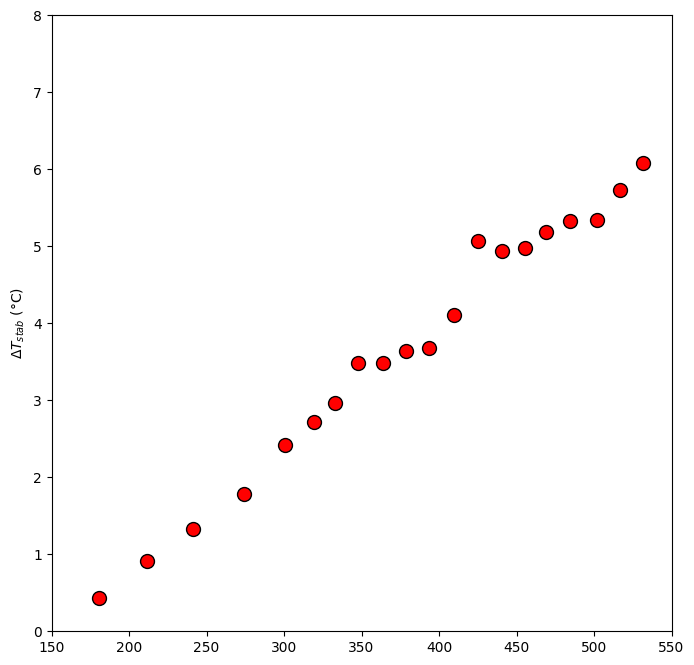

In [7]:
df_one["UTS(Mpa)"] = 607
df_one["Maximum stress"] = (df_one["UTS(Mpa)"] * df_one["Maximum Stress(%UTS)"]) / 100
df_one

plt.figure(figsize=(8, 8))
plt.scatter(df_one["Maximum stress"], df_one["Stabilised Temperature(degree C)"],c='red', marker='o', s=100, edgecolors='k')
plt.ylim(0, 8)
plt.xlim(150, 550)
plt.fontsize = 18
plt.ylabel("$\Delta T_{stab}$ (°C)")
plt.plot()

Splitting the data into training and testing for the first part of our ML/DL Pipeline.
We do a 50-50 random split based on our domain knowledge of data distribution

In [8]:
train_dfone = df_one.sample(frac = 0.5, random_state=42)
test_dfone = df_one.drop(train_dfone.index).reset_index(drop=True)
test_dfone

,Stabilised Temperature(degree C),Maximum Stress(%UTS),Material,UTS(Mpa),Maximum stress
0,1.327,39.724,Q1 CRPF Laminates,607,241.12468
1,2.422,49.556,Q1 CRPF Laminates,607,300.80492
2,2.960,54.804,Q1 CRPF Laminates,607,332.66028
3,3.479,57.247,Q1 CRPF Laminates,607,347.48929
4,3.644,62.415,Q1 CRPF Laminates,607,378.85905
5,3.682,64.851,Q1 CRPF Laminates,607,393.64557
6,5.064,70.038,Q1 CRPF Laminates,607,425.13066
7,4.935,72.619,Q1 CRPF Laminates,607,440.79733
8,4.973,74.981,Q1 CRPF Laminates,607,455.13467
9,6.087,87.617,Q1 CRPF Laminates,607,531.83519


In [9]:
train_dfone = train_dfone.reset_index(drop=True)
train_dfone

,Stabilised Temperature(degree C),Maximum Stress(%UTS),Material,UTS(Mpa),Maximum stress
0,0.428,29.748,Q1 CRPF Laminates,607,180.57036
1,5.343,82.662,Q1 CRPF Laminates,607,501.75834
2,5.179,77.272,Q1 CRPF Laminates,607,469.04104
3,0.917,34.847,Q1 CRPF Laminates,607,211.52129
4,3.488,59.978,Q1 CRPF Laminates,607,364.06646
5,2.715,52.586,Q1 CRPF Laminates,607,319.19702
6,4.113,67.514,Q1 CRPF Laminates,607,409.80998
7,1.786,45.118,Q1 CRPF Laminates,607,273.86626
8,5.725,85.177,Q1 CRPF Laminates,607,517.02439
9,5.325,79.857,Q1 CRPF Laminates,607,484.73199


In [10]:
#Fatigue Limit 
delta_fl = 77

In [11]:
train_dfone.columns

Index(['Stabilised Temperature(degree C)', 'Maximum Stress(%UTS)', 'Material ',
       'UTS(Mpa)', 'Maximum stress'],
      dtype='object')

Data augmentation is a technique used to artificially increase the size and diversity of a training dataset by applying various transformations to existing data samples. This helps to improve the performance and generalization ability of machine learning models, particularly when dealing with limited or imbalanced datasets

We augment our data based on finding the right curve fiting of the datapoints. We induce a slight noise to the points and thus get a distribution even where there is not enough data. Following is the function to carry out the data augmentation process 

<>:87: SyntaxWarning: invalid escape sequence '\D'
<>:87: SyntaxWarning: invalid escape sequence '\D'
/var/folders/dl/_w72qrpj6gs0p_2yyrq_pcdr0000gn/T/ipykernel_11721/3083418365.py:87: SyntaxWarning: invalid escape sequence '\D'
  plt.ylabel("$\Delta T_{stab}$ (°C)")


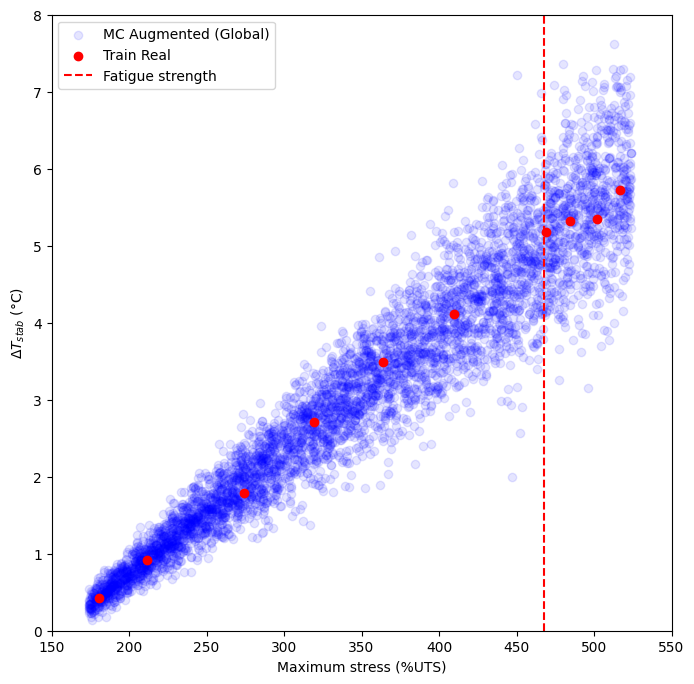

In [12]:
from scipy.optimize import curve_fit

def augment_SN_MC_global(
    train_SN,
    n_samples=5000,
    noise_level=0.15,  
    rng_seed=42
):
    rng = np.random.default_rng(rng_seed)
    
    s_real = train_SN["Maximum Stress(%UTS)"].to_numpy(float)
    t_real = train_SN["Stabilised Temperature(degree C)"].to_numpy(float)
    
    def physics_model(x, a, b, c):
        return a * np.exp(b * x) + c

    p0 = [0.15, 0.04, 0.0] 
    
    try:
        popt, _ = curve_fit(physics_model, s_real, t_real, p0=p0, maxfev=10000)
    except RuntimeError:
        print("Exponential fit failed, falling back to Polynomial (deg 3)")
        z = np.polyfit(s_real, t_real, 3)
        physics_model = lambda x, *args: np.polyval(z, x)
        popt = []

    # 3. Monte Carlo Simulation
    s_min, s_max = s_real.min(), s_real.max()
    s_range = s_max - s_min
    mc_stress = rng.uniform(s_min - 0.02*s_range, s_max + 0.02*s_range, n_samples)
    
    if len(popt) > 0:
        mc_temp_mean = physics_model(mc_stress, *popt)
    else:
        mc_temp_mean = physics_model(mc_stress)

    # C. Add Heteroscedastic Noise (Noise scales with magnitude)
    # Real data shows: Low Temp = Low Noise, High Temp = High Noise
    
    abs_noise = 0.05 
    rel_noise = mc_temp_mean * noise_level 
    
    sigma_noise = abs_noise + rel_noise
    
    # Generate noisy samples
    mc_temp = mc_temp_mean + rng.normal(0, sigma_noise)
    
    # 4. Physical Constraints
    mc_temp = np.maximum(mc_temp, 0.0) 
    mc_stress = np.maximum(mc_stress, 0.0)

    aug = pd.DataFrame({
        "Maximum stress(%UTS)": mc_stress,
        "Maximum stress": (mc_stress * 607) / 100,
        "Temp stabilisation":   mc_temp,
        "Source":               "augmented_MC",
        "sample_weight":        np.ones(n_samples)
    })
    
    real = pd.DataFrame({
        "Maximum stress(%UTS)": s_real,
        "Maximum stress": (s_real * 607) / 100,
        "Temp stabilisation":   t_real,
        "Source":               "real",
        "sample_weight":        np.ones(len(s_real))
    })
    
    combined = pd.concat([aug, real], ignore_index=True)
    
    return combined, aug, real, popt


combined_df, aug_df, real_df, params = augment_SN_MC_global(train_dfone, n_samples=5000, noise_level=0.12)

plt.figure(figsize=(8, 8))
plt.scatter(aug_df["Maximum stress"], aug_df["Temp stabilisation"], 
            c='blue', alpha=0.1, label='MC Augmented (Global)')
plt.scatter(real_df["Maximum stress"], real_df["Temp stabilisation"], 
            c='red', marker = 'o', label='Train Real')

#x_trend = np.linspace(real_df["Maximum stress(%UTS)"].min(), real_df["Maximum stress(%UTS)"].max(), 100)
#def func(x, a, b, c): return a * np.exp(b * x) + c
#if len(params) > 0:
#    plt.plot(x_trend, func(x_trend, *params), 'b--', label="fitted trend")

plt.xlabel("Maximum stress (%UTS)")
plt.ylabel("$\Delta T_{stab}$ (°C)")
plt.ylim(0, 8)
plt.xlim(150, 550)
plt.axvline(delta_fl* 6.07, color="red", ls="--", label="Fatigue strength")
#plt.title("Monte Carlo Augmentation")
plt.legend()
plt.show()

The above graph gives us a good visualisation for how the augmented data looks like

In [13]:
combined_df

,Maximum stress(%UTS),Maximum stress,Temp stabilisation,Source,sample_weight
0,73.255014,444.657936,3.971542,augmented_MC,1.0
1,53.939077,327.410196,2.567407,augmented_MC,1.0
2,78.134293,474.275159,5.289227,augmented_MC,1.0
3,68.840009,417.858855,3.863173,augmented_MC,1.0
4,34.068382,206.795082,0.815503,augmented_MC,1.0
...,...,...,...,...,...
5005,52.586000,319.197020,2.715000,real,1.0
5006,67.514000,409.809980,4.113000,real,1.0
5007,45.118000,273.866260,1.786000,real,1.0
5008,85.177000,517.024390,5.725000,real,1.0


Final Distribution of the Augmented values plotted with the real values 

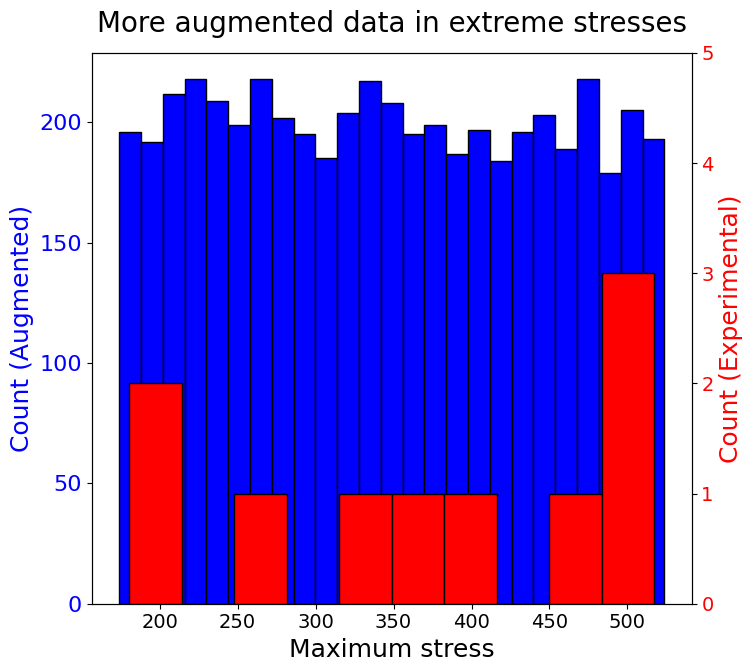

In [14]:
plt.rcParams.update({'font.size': 16})

fig, ax1 = plt.subplots(figsize=(8, 7))

ax1.hist(aug_df["Maximum stress"], bins=25, alpha=1,
         label="Augmented", color="b", edgecolor="k")
ax1.set_xlabel("Maximum stress", fontsize=18)
ax1.set_ylabel("Count (Augmented)", color="b", fontsize=18)
ax1.tick_params(axis='y', labelcolor='b')
ax1.tick_params(axis='x', labelsize=14)

ax2 = ax1.twinx()
ax2.hist(real_df["Maximum stress"], bins=10, alpha=1,
         label="Experimental", color="r", edgecolor="k")
ax2.set_ylabel("Count (Experimental)", color="r", fontsize=18)
ax2.tick_params(axis='y', labelcolor='r', labelsize=14)

plt.title("More augmented data in extreme stresses", fontsize=20, pad=15)
#fig.legend(loc="upper right", bbox_to_anchor=(1,1),
#           bbox_transform=ax1.transAxes, fontsize=14)

plt.tight_layout()
plt.ylim(0,5)
plt.show()

We will now use this Augmented dataset to build an XGBoost Model that will predict Temperature for a given stress value. This model is important because a good prediction here will allow us to map these temperature values for the corresponding stress values in the stress vs number of cycles dataset

In [15]:
test_dfone = test_dfone.rename(columns={"Stabilised Temperature(degree C)":"Temp stabilisation", "Maximum Stress(%UTS)": "Maximum stress(%UTS)"})

In [16]:
test_dfone

,Temp stabilisation,Maximum stress(%UTS),Material,UTS(Mpa),Maximum stress
0,1.327,39.724,Q1 CRPF Laminates,607,241.12468
1,2.422,49.556,Q1 CRPF Laminates,607,300.80492
2,2.960,54.804,Q1 CRPF Laminates,607,332.66028
3,3.479,57.247,Q1 CRPF Laminates,607,347.48929
4,3.644,62.415,Q1 CRPF Laminates,607,378.85905
5,3.682,64.851,Q1 CRPF Laminates,607,393.64557
6,5.064,70.038,Q1 CRPF Laminates,607,425.13066
7,4.935,72.619,Q1 CRPF Laminates,607,440.79733
8,4.973,74.981,Q1 CRPF Laminates,607,455.13467
9,6.087,87.617,Q1 CRPF Laminates,607,531.83519


The rapid growth of data science and computational power has led to the rise of machine learning (ML) as a powerful tool in various fields, including the modeling of composite materials . Machine learning also offers great potential for efficient and accurate prediction of the fatigue strength and life of composite materials. Linear regression, random forest regression, support vector regression, and artificial neural networks, among others, are commonly used ML-based regression algorithms for fatigue life prediction.

Defining the Input/Output features of the Model 

In [17]:
features = ["Maximum stress"]

X_train = combined_df[features]
X_test = test_dfone[features]
y_train = combined_df["Temp stabilisation"]
y_test = test_dfone["Temp stabilisation"]

Model Architecture of an XGBoost 

In [18]:
w_train = combined_df["sample_weight"].to_numpy()
model_xgb = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)
model_xgb.fit(X_train, y_train, sample_weight=w_train)
new_preds = model_xgb.predict(X_test)

r2 = r2_score(y_test, new_preds)
#As we can see, the r2 value is excellent. This allows us to use this model for our further predictions
print(r2)

0.9426995680400924


Following is the plot to show actual vs predicted for the trained model 

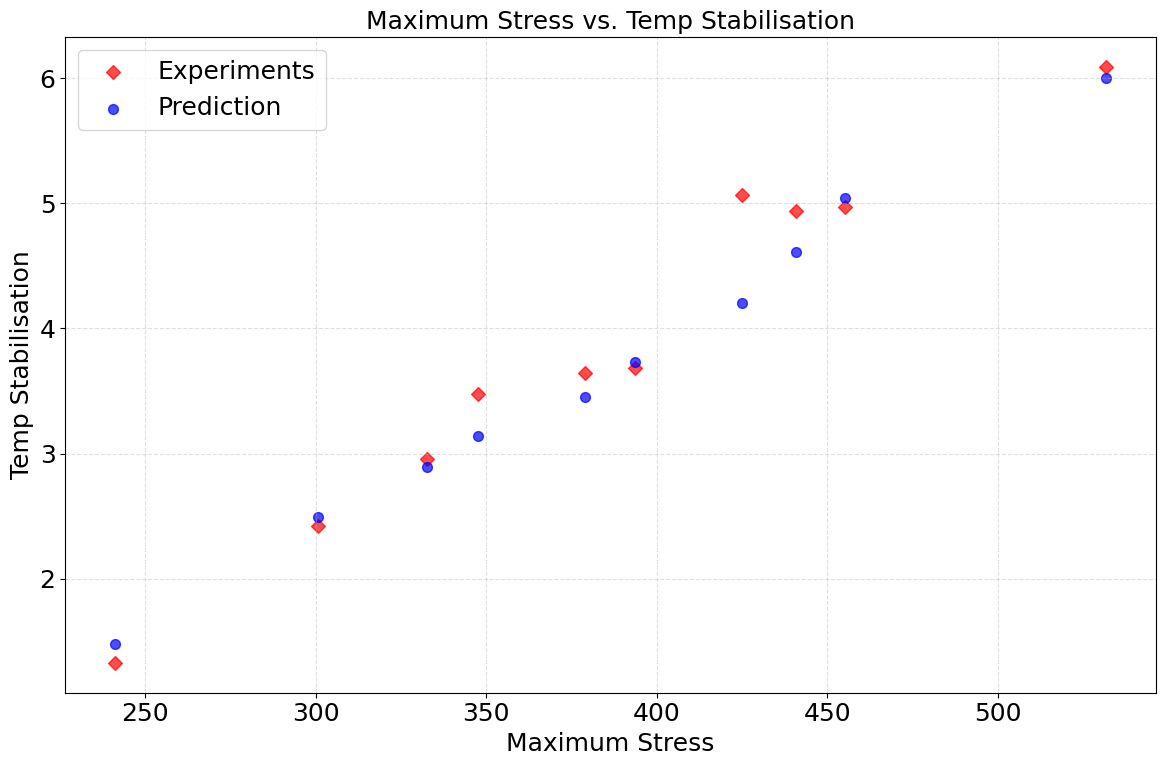

In [19]:
import matplotlib.pyplot as plt

plt.rc('font', size=18) 

plt.figure(figsize=(12, 8))

plt.scatter(
    X_test["Maximum stress"], 
    y_test, 
    color='red', 
    label='Experiments', 
    marker='D', 
    s=50,       
    alpha=0.7
)

plt.scatter(
    X_test["Maximum stress"], 
    new_preds, 
    color='blue', 
    label='Prediction', 
    marker='o', 
    s=50, 
    alpha=0.7
)

plt.title('Maximum Stress vs. Temp Stabilisation', fontsize=18)
plt.xlabel('Maximum Stress', fontsize=18)
plt.ylabel('Temp Stabilisation', fontsize=18)
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
plt.legend(fontsize=18)
plt.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

As we can see, our approach to the augmentation with a curve fit allows us to predict values with a noise even in the scarcity of data points. This allows us to get a very good r2 value concluding our model building 

Importing our stress vs number of cycles dataset 

In [ ]:
file = r"StressvsNumberofcycles.xlsx"

df = pd.read_excel(file)

df.to_csv("StressvsNumberofcycles_one.csv", index=False)

In [21]:
df

,Maximum Stress(%UTS),Number of cycles,Material
0,89.740,9333,Q1 CFRP laminates
1,89.750,59134,Q1 CFRP laminates
2,89.844,120918,Q1 CFRP laminates
3,84.896,62728,Q1 CFRP laminates
4,84.844,69120,Q1 CFRP laminates
5,84.792,130968,Q1 CFRP laminates
6,79.688,144544,Q1 CFRP laminates
7,79.844,212132,Q1 CFRP laminates
8,79.740,291094,Q1 CFRP laminates
9,79.750,478631,Q1 CFRP laminates


In [22]:
df = df.drop([15,16,17,18,19,20,21,22,23,24,25,26,27,28,29])
df

,Maximum Stress(%UTS),Number of cycles,Material
0,89.740,9333,Q1 CFRP laminates
1,89.750,59134,Q1 CFRP laminates
2,89.844,120918,Q1 CFRP laminates
3,84.896,62728,Q1 CFRP laminates
4,84.844,69120,Q1 CFRP laminates
5,84.792,130968,Q1 CFRP laminates
6,79.688,144544,Q1 CFRP laminates
7,79.844,212132,Q1 CFRP laminates
8,79.740,291094,Q1 CFRP laminates
9,79.750,478631,Q1 CFRP laminates


In [23]:
df["Maximum stress"] = (df["Maximum Stress(%UTS)"] * 607) / 100
df["log cycles"] = np.log10(df["Number of cycles"])
df

,Maximum Stress(%UTS),Number of cycles,Material,Maximum stress,log cycles
0,89.740,9333,Q1 CFRP laminates,544.72180,3.970021
1,89.750,59134,Q1 CFRP laminates,544.78250,4.771837
2,89.844,120918,Q1 CFRP laminates,545.35308,5.082491
3,84.896,62728,Q1 CFRP laminates,515.31872,4.797461
4,84.844,69120,Q1 CFRP laminates,515.00308,4.839604
5,84.792,130968,Q1 CFRP laminates,514.68744,5.117165
6,79.688,144544,Q1 CFRP laminates,483.70616,5.160000
7,79.844,212132,Q1 CFRP laminates,484.65308,5.326606
8,79.740,291094,Q1 CFRP laminates,484.02180,5.464033
9,79.750,478631,Q1 CFRP laminates,484.08250,5.680001


The following scatter plot shows the how the S-N Curve looks like for the data

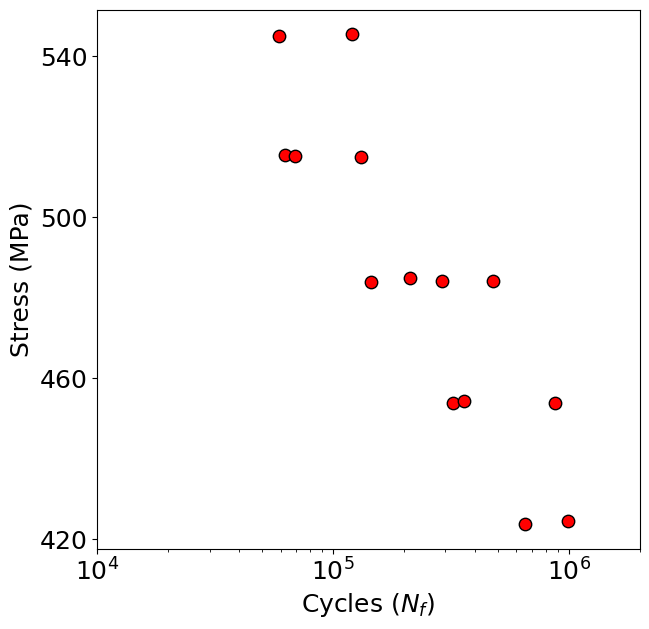

In [24]:
plt.figure(figsize=(7, 7))
plt.xscale('log')
plt.scatter(df["Number of cycles"], df["Maximum stress"],c='red', marker='o', s=80, edgecolors='k')
plt.xlabel('Cycles ($N_f$)', fontsize=18)
plt.ylabel('Stress (MPa)', fontsize=18)
plt.xlim(1e4,2*1e6)
plt.yticks([420, 460, 500, 540])
#plt.ylim(420, 550
plt.show()

In [25]:
df["Source"] = "real"
df

,Maximum Stress(%UTS),Number of cycles,Material,Maximum stress,log cycles,Source
0,89.740,9333,Q1 CFRP laminates,544.72180,3.970021,real
1,89.750,59134,Q1 CFRP laminates,544.78250,4.771837,real
2,89.844,120918,Q1 CFRP laminates,545.35308,5.082491,real
3,84.896,62728,Q1 CFRP laminates,515.31872,4.797461,real
4,84.844,69120,Q1 CFRP laminates,515.00308,4.839604,real
5,84.792,130968,Q1 CFRP laminates,514.68744,5.117165,real
6,79.688,144544,Q1 CFRP laminates,483.70616,5.160000,real
7,79.844,212132,Q1 CFRP laminates,484.65308,5.326606,real
8,79.740,291094,Q1 CFRP laminates,484.02180,5.464033,real
9,79.750,478631,Q1 CFRP laminates,484.08250,5.680001,real


Following is the function to plot out the derivatives graph. All of these helper plotting functions are utilised to build the necessary graphs to showcase how the predictions and results look like 

In [26]:
def check_derivatives(model, scaler, device):
    """Visualizes if the model respects the physics constraint (dLife/dStress < 0)"""
    stress_range = np.linspace(200, 600, 100).reshape(-1, 1)
    temp_range = np.zeros_like(stress_range) 
    
    # Prepare input
    X_grid = np.column_stack([stress_range, temp_range])
    X_grid_s = scaler.transform(X_grid)
    X_tensor = torch.tensor(X_grid_s, dtype=torch.float32, device=device, requires_grad=True)
    
    # Get Gradients
    model.eval()
    logN_pred = model(X_tensor)
    grads = torch.autograd.grad(logN_pred, X_tensor, torch.ones_like(logN_pred), create_graph=True)[0]
    dLogN_dStress = grads[:, 0].cpu().detach().numpy() 
    
    # Plot
    plt.figure(figsize=(6, 4))
    plt.plot(stress_range, dLogN_dStress, color='purple', lw=2)
    plt.axhline(0, color='red', linestyle='--', label='Physics Limit (0)')
    plt.fill_between(stress_range.flatten(), dLogN_dStress, 0, where=(dLogN_dStress > 0), color='red', alpha=0.3, label='Violation')
    plt.fill_between(stress_range.flatten(), dLogN_dStress, 0, where=(dLogN_dStress < 0), color='green', alpha=0.1, label='Valid')
    plt.ylabel("Gradient (dLife/dStress)")
    plt.xlabel("Stress")
    plt.title("Physics Check: Is the derivative negative?")
    plt.legend()
    plt.show()

In [27]:
from scipy.stats import linregress

Added a feature column that helps during the data augmentation step

In [28]:
df["Run Out"] = np.where(df["Number of cycles"] > 990000, "yes", "no")
df

,Maximum Stress(%UTS),Number of cycles,Material,Maximum stress,log cycles,Source,Run Out
0,89.740,9333,Q1 CFRP laminates,544.72180,3.970021,real,no
1,89.750,59134,Q1 CFRP laminates,544.78250,4.771837,real,no
2,89.844,120918,Q1 CFRP laminates,545.35308,5.082491,real,no
3,84.896,62728,Q1 CFRP laminates,515.31872,4.797461,real,no
4,84.844,69120,Q1 CFRP laminates,515.00308,4.839604,real,no
5,84.792,130968,Q1 CFRP laminates,514.68744,5.117165,real,no
6,79.688,144544,Q1 CFRP laminates,483.70616,5.160000,real,no
7,79.844,212132,Q1 CFRP laminates,484.65308,5.326606,real,no
8,79.740,291094,Q1 CFRP laminates,484.02180,5.464033,real,no
9,79.750,478631,Q1 CFRP laminates,484.08250,5.680001,real,no


This ensures reproducibility

In [29]:
import random 
def set_seed(seed=42):
    """
    Locks the random state for Python, NumPy, and PyTorch.
    Ensures that augmentation, weight initialization, and data splits are identical every run.
    """
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    
    print(f"Global Random Seed set to: {seed}")

Data Augmentation is established using a Basquin relationship where we assign two highest stress levels that lead to early failure. This approach shows that, for fatigue datasets exhibiting large scatter due to experimental repeats, it is not necessary to perform data augmentation between the extreme stress values.

In [30]:
#Helper Function
def assign_stress_levels(df, tolerance=10.0):

    unique_stresses = sorted(df['Maximum stress'].unique(), reverse=True)
    
    level_map = {}
    current_level_id = 1
    
    if not unique_stresses: return df
    
    reference_stress = unique_stresses[0]
    level_map[reference_stress] = current_level_id
    
    for s in unique_stresses[1:]:
        if abs(s - reference_stress) <= tolerance:
            level_map[s] = current_level_id
        else:
            current_level_id += 1
            reference_stress = s
            level_map[s] = current_level_id
            
    df = df.copy()
    df['stress_level_id'] = df['Maximum stress'].map(level_map)
    return df

In [31]:
import scipy.stats as stats

Final Data Augmentation function that adds 1000 datapoints to the original dataset

In [32]:
def augment_training_data(df, n_aug=1000):
    """
    Use run-outs ONLY to stabilize the fitted trend (slope/intercept),
    but exclude run-outs from the returned dataset used for PINN training.
    """
    df_fit = df.copy() 
    if "Run Out" in df.columns:
        df_train = df[df["Run Out"] != "yes"].copy()  # failures only
    else:
        df_train = df.copy()

    df_fit = assign_stress_levels(df_fit, tolerance=15.0)

    grp_stats = (df_fit.groupby("stress_level_id")["Maximum stress"]
                   .mean()
                   .sort_values(ascending=False))
    top_ids = grp_stats.index[:2].tolist()
    if len(top_ids) < 2:
        return df_train  

    group1 = df_fit[df_fit["stress_level_id"] == top_ids[0]]
    group2 = df_fit[df_fit["stress_level_id"] == top_ids[1]]
    if group1.empty or group2.empty:
        return df_train

    x1 = np.mean(np.log10(group1["Number of cycles"].values))
    y1 = np.mean(group1["Maximum stress"].values)
    x2 = np.mean(np.log10(group2["Number of cycles"].values))
    y2 = np.mean(group2["Maximum stress"].values)

    subset = pd.concat([group1, group2], ignore_index=True)

    dx = (x2 - x1)
    if abs(dx) < 0.15:
        X_sub = np.log10(subset["Number of cycles"].values).reshape(-1, 1)
        y_sub = subset["Maximum stress"].values
        reg = LinearRegression().fit(X_sub, y_sub)
        slope = float(reg.coef_[0])
        intercept = float(reg.intercept_)
    else:
        slope = (y2 - y1) / dx
        intercept = y1 - slope * x1

    df_sigma = df_train.copy()
    df_sigma = assign_stress_levels(df_sigma, tolerance=15.0)
    grp_stats2 = (df_sigma.groupby("stress_level_id")["Maximum stress"]
                    .mean()
                    .sort_values(ascending=False))
    top_ids2 = grp_stats2.index[:2].tolist()

    if len(top_ids2) >= 2:
        g1s = df_sigma[df_sigma["stress_level_id"] == top_ids2[0]]
        g2s = df_sigma[df_sigma["stress_level_id"] == top_ids2[1]]
        subset_s = pd.concat([g1s, g2s], ignore_index=True)
        x_sub = np.log10(subset_s["Number of cycles"].values)
        y_sub = subset_s["Maximum stress"].values
        y_pred_sub = slope * x_sub + intercept
        residuals = y_sub - y_pred_sub
    else:
        residuals = np.array([])

    sigma_noise = np.std(residuals, ddof=1) if len(residuals) > 2 else 5.0

    min_log_cycle = np.log10(df_train["Number of cycles"].min())
    max_log_cycle = min(6.0, float(df_train["log cycles"].max()) + 0.2)

    x_aug = np.random.uniform(min_log_cycle, max_log_cycle, n_aug)
    y_aug_mean = slope * x_aug + intercept
    noise = np.random.normal(0, sigma_noise, n_aug)
    y_aug_uts = y_aug_mean + noise

    max_stress_real = float(df_fit["Maximum stress"].max())
    y_aug_uts = np.clip(y_aug_uts, 0.0, 1.02 * max_stress_real)

    UTS = 607.0
    y_aug_mpa = (y_aug_uts * 100.0) / UTS

    df_noise = len(residuals) - 1
    t_multiplier = stats.t.ppf((1 + 0.95) / 2, df_noise) if df_noise > 0 else 1.96
    bound_95 = t_multiplier * sigma_noise
    print(f"Standard Deviation (1 sigma): {sigma_noise:.2f}")
    print(f"95% Confidence Bound:        {bound_95:.2f}")
    within_bound = np.sum(np.abs(noise) <= bound_95)
    percent = (within_bound / n_aug) * 100
    print(f"Actual noise within bound:   {percent:.2f}%")

    df_aug = pd.DataFrame({
        "log cycles": x_aug,
        "Maximum stress": y_aug_uts,
        "Number of cycles": 10**x_aug,
        "Maximum stress(%UTS)": y_aug_mpa,
        "Source": "augmented",
        "Run Out": "no"
    })


    return pd.concat([df_train, df_aug], ignore_index=True)


We propose a Physics Informed Neural Network for effective Fatigue life prediction. PINNs in general are architectures that can embed the knowledge of any physical laws that govern a given data-set in the learning process. The prior knowledge of general physical laws acts in the training of neural networks (NNs) as a regularization agent that limits the space of admissible solutions, increasing the generalizability of the function approximation

In [33]:
device = torch.device("mps" if torch.backends.mps.is_available() else
                      "cuda" if torch.cuda.is_available() else "cpu")
print(f"Running on: {device}")

class LifeNet(nn.Module):
    def __init__(self, in_dim=2, hidden=64, out_dim=1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden), nn.Tanh(),
            nn.Linear(hidden, hidden), nn.Tanh(),
            nn.Linear(hidden, out_dim)
        )
        
    def forward(self, x):
        return self.net(x)

def physics_loss(model, X_phys):
    """Enforces: Life decreases as Stress or Temp increases."""
    Xp = X_phys.clone().detach().requires_grad_(True)
    logN_pred = model(Xp)
    grads = torch.autograd.grad(logN_pred, Xp, torch.ones_like(logN_pred), create_graph=True)[0]
    
    # penalty = ReLU( dLogN/dStress ) + ReLU( dLogN/dTemp )
    penalty = torch.relu(grads[:, 0:1]) + torch.relu(grads[:, 1:2])
    return torch.mean(penalty**2)

# --- 3. AUGMENTATION ENGINE ---
# def augment_training_data(df, n_aug=1000):
#     """
#     Augmentation Strategy: 'Top 2 Levels Centroid' (Robust)
#     Uses gap-tolerance to correctly identify top levels, avoiding rounding errors.
#     """
#     # 1. Robust Level Identification
#     df = assign_stress_levels(df, tolerance=15.0) # 15 MPa tolerance 
    
#     grp_stats = (df.groupby("stress_level_id")["Maximum stress"]
#                .mean()
#                .sort_values(ascending=False))

#     top_ids = grp_stats.index[:2].tolist()

#     if len(top_ids) < 2:
#         # not enough distinct stress levels to fit a line
#         return df

#     group1 = df[df["stress_level_id"] == top_ids[0]]
#     group2 = df[df["stress_level_id"] == top_ids[1]]
#     # 2. Identify Top 2 Levels by ID
#     # We want Level ID 1 and Level ID 2
#     # group1 = df[df['stress_level_id'] == 1]
#     # group2 = df[df['stress_level_id'] == 2]

#     # 3. Calculate Centroids
#     x1 = np.mean(np.log10(group1["Number of cycles"].values))
#     y1 = np.mean(group1["Maximum stress"].values)
    
#     x2 = np.mean(np.log10(group2["Number of cycles"].values))
#     y2 = np.mean(group2["Maximum stress"].values)
    
#     # 4. Calculate Slope
#     slope = (y2 - y1) / (x2 - x1)
#     intercept = y1 - slope * x1
    
#     # Calculate Noise
#     subset = pd.concat([group1, group2])
#     x_sub = np.log10(subset["Number of cycles"].values)
#     y_sub = subset["Maximum stress"].values
    
#     y_pred_sub = slope * x_sub + intercept
#     residuals = y_sub - y_pred_sub
#     sigma_noise = np.std(residuals, ddof=1) if len(residuals) > 1 else 5.0

#     # 5. Generate Augmentation
#     min_log_cycle = np.log10(df["Number of cycles"].min())
#     max_log_cycle = 6.0 

#     x_aug = np.random.uniform(min_log_cycle, max_log_cycle, n_aug)
#     y_aug_mean = slope * x_aug + intercept

#     # Add Noise
#     noise = np.random.normal(0, sigma_noise, n_aug)
#     y_aug_uts = y_aug_mean + noise

#     y_aug_mpa = (y_aug_uts * 100) / 607 
#     import scipy.stats as stats

# # 1. Calculate the 95% Confidence Bound (Prediction Interval)
#     confidence_level = 0.95
#     df_noise = len(residuals) - 1
#     t_multiplier = stats.t.ppf((1 + 0.95) / 2, df_noise) if df_noise > 0 else 1.96

#     bound_95 = t_multiplier * sigma_noise

# # 2. Check the results
#     print(f"Standard Deviation (1 sigma): {sigma_noise:.2f}")
#     print(f"95% Confidence Bound:        {bound_95:.2f}")

# # 3. Verification
#     within_bound = np.sum(np.abs(noise) <= bound_95)
#     percent = (within_bound / n_aug) * 100
#     print(f"Actual noise within bound:   {percent:.2f}%")

#     df_aug = pd.DataFrame({
#         "log cycles": x_aug,
#         "Maximum stress": y_aug_uts, 
#         "Number of cycles": 10**x_aug,
#         "Maximum stress(%UTS)": y_aug_mpa, 
#         "Source": "augmented"
#     })
    

#     return pd.concat([df, df_aug], ignore_index=True)


def train_and_evaluate_fold(train_df, test_df, xgb_model, epochs=500, verbose=False, plot_diagnostics=False):
    """
    Encapsulates the entire process for ONE fold:
    Augment -> Predict Temp -> Scale -> Train PINN -> Evaluate
    """
    # A. Augment (Only Training Data)
    train_aug = augment_training_data(train_df)
    
    # B. Fill Temperatures (using your XGB model)
    train_aug["Predicted Temperature"] = xgb_model.predict(train_aug[["Maximum stress"]])
    test_df = test_df.copy() 
    test_df["Predicted Temperature"] = xgb_model.predict(test_df[["Maximum stress"]])
    
    # C. Prepare Tensors
    X_train = train_aug[["Maximum stress", "Predicted Temperature"]].values
    y_train = train_aug["log cycles"].values.reshape(-1, 1)
    X_test  = test_df[["Maximum stress", "Predicted Temperature"]].values
    y_test  = test_df["log cycles"].values.reshape(-1, 1)
    
    # Scale
    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train)
    X_test_s  = scaler.transform(X_test)
    
    # To GPU
    X_tr_t = torch.tensor(X_train_s, dtype=torch.float32, device=device)
    y_tr_t = torch.tensor(y_train, dtype=torch.float32, device=device)
    X_te_t = torch.tensor(X_test_s, dtype=torch.float32, device=device)
    
    # D. Train PINN
    model = LifeNet(hidden=64).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.002)
    
    history_data = [] 
    history_phys = []

    model.train()
    for ep in range(epochs):
        optimizer.zero_grad()
        pred = model(X_tr_t)
        loss_d = nn.MSELoss()(pred, y_tr_t)
        loss_p = physics_loss(model, X_tr_t)
        loss = loss_d + 0.1 * loss_p
        loss.backward()
        optimizer.step()
        
        history_data.append(loss_d.item())
        history_phys.append(loss_p.item())
    
    if plot_diagnostics:
        # Plot 1: Loss Curves
        plt.figure(figsize=(10, 4))
        plt.subplot(1, 2, 1)
        plt.plot(history_data, label='Data Loss (MSE)')
        plt.plot(history_phys, label='Physics Loss')
        plt.yscale('log')
        plt.legend()
        plt.title("Is the model fighting physics?")
        
        plt.subplot(1, 2, 2)
        X_viz = X_tr_t.clone().detach().requires_grad_(True)
        pred_viz = model(X_viz)
        
        grads = torch.autograd.grad(
            outputs=pred_viz, 
            inputs=X_viz, 
            grad_outputs=torch.ones_like(pred_viz), 
            create_graph=False 
        )[0]
        
        stress_grads = grads[:, 0].cpu().detach().numpy()
        plt.hist(stress_grads, bins=30, color='purple', alpha=0.7)
        plt.axvline(0, color='red', linestyle='--')
        plt.xlabel("dLife/dStress Gradient")
        plt.title("Gradients (Should be < 0)")
        plt.tight_layout()
        plt.show()
        
        check_derivatives(model, scaler, device)
    model.eval()
    with torch.no_grad():
        logN_pred = model(X_te_t).cpu().numpy()
    
    rmse = np.sqrt(np.mean((logN_pred - y_test)**2))
    return rmse

Running on: mps


Finding the optimal K Fold Cross Validation Strategy

K fold stability analysis. We implement a K fold strategy where we run the model from K = 2 to K = N - 1, N being the number of samples. This allows us to find the best validation strategy for our dataset 

In [34]:
from sklearn.model_selection import KFold, RepeatedKFold

In [ ]:
set_seed(42)
def find_optimal_k(df, model_xgb, n_repeats=5):
    """
    Runs repeated CV for ALL possible K values (from 2 to N).
    Best for small datasets (N < 50).
    """
    N = len(df)
    k_candidates = range(2, N + 1) 
    
    results = {k: [] for k in k_candidates}
    
    print(f"Starting Exhaustive Stability Analysis (N={N} samples)...")
    
    for k in k_candidates:
        print(f"Processing K={k}...", end=" ")
        
        rkf = RepeatedKFold(n_splits=k, n_repeats=n_repeats, random_state=42)
        
        k_scores = []
        
        for train_idx, test_idx in rkf.split(df):
            train_fold = df.iloc[train_idx].copy()
            test_fold  = df.iloc[test_idx].copy()
            
            rmse = train_and_evaluate_fold(train_fold, test_fold, model_xgb, epochs=500)
            k_scores.append(rmse)
        
        results[k] = k_scores
        print(f"Mean RMSE: {np.mean(k_scores):.4f}")
        
    return results

stats = find_optimal_k(df, model_xgb, n_repeats=3)

def plot_stability(stats, tick_step=3):
    means = [np.mean(stats[k]) for k in stats]
    stds  = [np.std(stats[k]) for k in stats]
    ks    = list(stats.keys())

    plt.figure(figsize=(10, 6))
    
    plt.errorbar(
        ks, means, yerr=stds, fmt='-o', capsize=5,
        color='tab:blue', ecolor='tab:red',
        linewidth=2, label='RMSE Variability'
    )

    plt.xlabel("Number of Folds (k)", fontsize=12)
    plt.ylabel("RMSE (Log Cycles)", fontsize=12)

    tick_positions = ks[::tick_step]
    if ks[-1] not in tick_positions:
        tick_positions.append(ks[-1])

    plt.xticks(tick_positions)

    plt.grid(True, linestyle='--', alpha=0.5)

    plt.legend()
    plt.tight_layout()
    plt.show()


# --- PLOTTING(Continuous K) ---
# def plot_stability(stats):
#     means = [np.mean(stats[k]) for k in stats]
#     stds  = [np.std(stats[k]) for k in stats]
#     ks    = list(stats.keys())

#     plt.figure(figsize=(10, 6))
    
#     # Error Bar Plot
#     plt.errorbar(ks, means, yerr=stds, fmt='-o', capsize=5, 
#                  color='tab:blue', ecolor='tab:red', linewidth=2, label='RMSE Variability')
    
#     plt.xlabel("Number of Folds (k)", fontsize=12)
#     plt.ylabel("RMSE (Log Cycles)", fontsize=12)
#     plt.title(f"Stability Analysis (K=2 to {max(ks)})", fontsize=14)
    
#     # Ensure x-axis shows integers only
#     plt.xticks(ks) 
#     plt.grid(True, linestyle='--', alpha=0.5)
    
#     best_k_idx = np.argmin(stds)
#     best_k = ks[best_k_idx]
#     plt.annotate(f'Most Stable (k={best_k})', 
#                  xy=(best_k, means[best_k_idx]), 
#                  xytext=(60, 100),  # move the text 40 points above the marker
#                 textcoords='offset points',
#                 ha='center',
#                 arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=8)
#     )
#     plt.legend()
#     plt.show()
    
plot_stability(stats)

Global Random Seed set to: 42
Starting Exhaustive Stability Analysis (N=15 samples)...
Processing K=2... Standard Deviation (1 sigma): 5.46
95% Confidence Bound:        17.39
Actual noise within bound:   99.90%


Creating a table with all the possible K folds and the corresponding RMSE Values that allow us to choose the correct fold

In [40]:
def make_k_table(stats):
    rows = []
    for k, scores in stats.items():
        rows.append({
            "k": k,
            "RMSE_mean": float(np.mean(scores)),
            "RMSE_std":  float(np.std(scores)),   # variability / s.d.
        })
    return pd.DataFrame(rows).sort_values("k").reset_index(drop=True)

k_table = make_k_table(stats)
print(k_table)

     k  RMSE_mean  RMSE_std
0    2   0.435839  0.154699
1    3   0.444147  0.201505
2    4   0.421239  0.226388
3    5   0.441893  0.287430
4    6   0.416083  0.276129
5    7   0.374048  0.254727
6    8   0.357190  0.288022
7    9   0.356836  0.276710
8   10   0.338628  0.273557
9   11   0.371138  0.318110
10  12   0.333489  0.309306
11  13   0.332302  0.295861
12  14   0.351088  0.340569
13  15   0.333298  0.345134


Function to visualize the Augmented data within a representative fold

In [35]:
def visualize_fold_augmentation(df_combined, fold_idx):
    """
    Robust Visualization using Tolerance-Based Grouping.
    Mirrors augmentation logic: top-2 groups by mean stress + dx-guard fallback.
    """
    real = df_combined[df_combined["Source"] != "augmented"].copy()
    synth = df_combined[df_combined["Source"] == "augmented"].copy()

    if "Run Out" in real.columns:
        real = real[real["Run Out"] != "yes"].copy()

    plt.figure(figsize=(8, 8))

    plt.scatter(synth["log cycles"], synth["Maximum stress"],
                c='tab:blue', alpha=0.15, s=15, label='Augmented Data')
    plt.scatter(real["log cycles"], real["Maximum stress"],
                c='red', marker='o', s=120, edgecolors='k', linewidth=1.5,
                zorder=10, label='Real Training Data')

    real = assign_stress_levels(real, tolerance=15.0)

    grp_stats = (real.groupby("stress_level_id")["Maximum stress"]
                   .mean()
                   .sort_values(ascending=False))
    top_ids = grp_stats.index[:2].tolist()

    g1 = real[real["stress_level_id"] == top_ids[0]] if len(top_ids) > 0 else real.iloc[0:0]
    g2 = real[real["stress_level_id"] == top_ids[1]] if len(top_ids) > 1 else real.iloc[0:0]

    if (not g1.empty) and (not g2.empty):
        x1 = np.mean(np.log10(g1["Number of cycles"].values))
        y1 = np.mean(g1["Maximum stress"].values)
        x2 = np.mean(np.log10(g2["Number of cycles"].values))
        y2 = np.mean(g2["Maximum stress"].values)

        plt.scatter(x1, y1, c='green', marker='*', s=250, zorder=15, edgecolors='k', label='Centroids')
        plt.scatter(x2, y2, c='green', marker='*', s=250, zorder=15, edgecolors='k')

        dx = (x2 - x1)
        if abs(dx) < 0.15:
            from sklearn.linear_model import LinearRegression
            subset = pd.concat([g1, g2], ignore_index=True)
            X_sub = np.log10(subset["Number of cycles"].values).reshape(-1, 1)
            y_sub = subset["Maximum stress"].values
            reg = LinearRegression().fit(X_sub, y_sub)
            slope = float(reg.coef_[0])
            intercept = float(reg.intercept_)
        else:
            slope = (y2 - y1) / dx
            intercept = y1 - slope * x1
    else:
        slope = 0.0
        intercept = float(real["Maximum stress"].mean())

    x_line = np.linspace(real["log cycles"].min(), synth["log cycles"].max(), 200)
    y_center = slope * x_line + intercept

    y_max = float(real["Maximum stress"].max())
    y_center = np.clip(y_center, 0.0, 1.02 * y_max)

    bound_95 = 17.39
    y_upper = y_center + bound_95
    y_lower = y_center - bound_95

    plt.fill_between(x_line, y_lower, y_upper, color='tab:blue', alpha=0.1, label='95% Noise Bound')
    plt.plot(x_line, y_upper, color='tab:blue', linestyle=':', alpha=0.3)
    plt.plot(x_line, y_lower, color='tab:blue', linestyle=':', alpha=0.3)

    plt.plot(x_line, y_center, 'k--', linewidth=2, label='Centroid Fit')

    plt.xlabel(r"Log Cycles ($\log_{10}N$)")
    plt.ylabel("Maximum Stress (MPa)")
    plt.grid(True, linestyle='--', alpha=0.4)

    ax = plt.gca()
    ax.margins(x=0.05, y=0.1)
    ax.set_xticks([3, 4, 5, 6, 7])
    ax.set_xticklabels([r'$10^3$', r'$10^4$', r'$10^5$', r'$10^6$', r'$10^7$'])

    plt.tight_layout()
    plt.show()


In [36]:
def plot_augmented_stress_vs_temp(train_aug):
    """
    Plots Stress vs Predicted Temperature.
    Size: 8x8
    """
    synth = train_aug[train_aug["Source"] == "augmented"]

    plt.figure(figsize=(8, 8))
    
    plt.scatter(synth["Maximum stress"], synth["Predicted Temperature"], 
                c='tab:blue', marker='o', s=50, alpha=0.3, label='Trained XGBoost Predictions')
    
    plt.scatter(df_one["Maximum stress"], df_one["Stabilised Temperature(degree C)"], 
                c='red', marker='o', s=120, edgecolors='k', linewidth=1.5, zorder=10, label='Experimental Data')
    
    plt.ylabel("Predicted Temperature (°C)", fontsize=18)
    plt.xlabel("Maximum Stress (MPa)", fontsize=18)
    plt.title("Stress vs. Predicted Temperature", fontsize=18)
    
    plt.legend(loc='upper left', frameon=True, fontsize=14)
    plt.grid(True, linestyle='--', alpha=0.4)
    
    ax = plt.gca()
    ax.tick_params(axis='both', which='major', labelsize=18)
    ax.tick_params(axis='both', which='minor', labelsize=18)
    plt.axvline(delta_fl* 6.07, color="red", ls="--", label="Fatigue strength")
    
    plt.tight_layout()
    plt.show()

Evaluation Metrics function. The evaluation metrics used in the analysis are as follows:
1. R^2; R squared ; Higher the value, closer to 1 is better
2. RMSE; Root mean squared error ; Lower the value the better

In [37]:
from sklearn.metrics import r2_score

def print_model_report_card(y_true, y_pred):
    """
    Calculates relative metrics to contextualize RMSE.
    Expects y_true and y_pred to be in Log10 scale.
    """
    rmse = np.sqrt(np.mean((y_pred - y_true)**2))

    factor_err = 10**rmse
    
    data_range = np.max(y_true) - np.min(y_true)
    nrmse = (rmse / data_range) * 100
    
    # 4. R2 Score
    r2 = r2_score(y_true, y_pred)
    
    print("-" * 30)
    print("MODEL PERFORMANCE REPORT")
    print("-" * 30)
    print(f"RMSE (Log Units):      {rmse:.4f}")
    print(f"Avg Error Factor:      {factor_err:.2f}x (Life prediction is within factor of {factor_err:.1f})")
    print(f"Normalized RMSE:       {nrmse:.2f}% of data range")
    print(f"R² Score:              {r2:.4f}")
    print("-" * 30)
    
    if factor_err < 2.0:
        print("VERDICT: EXCELLENT (Within standard experimental scatter)")
    elif factor_err < 3.0:
        print("VERDICT: ACCEPTABLE (Standard for high-scatter)")
    else:
        print("VERDICT: HIGH ERROR (Model may be underfitting)")


In the following function execution we see a graph on the upper right part for the comparison between the physics loss and the data loss. The graph reflects the training phase, where the model is updating its internal weights while going through the training set. 
As we see from the graph, both the physics loss and data loss is going down. It means our data is physically consistent with the constraints. 

Updated Functions for training the final PINN model with the correct K fold and data augmentation strategy

In [38]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler

def run_final_pipeline(
    df,
    xgb_model,
    best_k,
    device,
    epochs=1000,
    lr=0.002,
    lam_phys=0.1,
    do_plots_first_fold=True
):
    """
    Trains a K-fold ensemble of PINNs and stores:
      - loss histories (data, phys, phys-share, TEST MSE)
      - per-point physics violation on the augmented training set
      - training fold inputs (stress/temp/logN) for analysis
      - per-fold TRAIN/TEST metrics (on log10 life): MSE, RMSE, MAE, R2

    Returns:
      ensemble_models, metrics_table
    """
    print(f"\nTraining Final Ensemble with K={best_k}")
    kf = KFold(n_splits=best_k, shuffle=True, random_state=42)

    ensemble_models = []
    metrics_rows = []

    for fold, (train_idx, test_idx) in enumerate(kf.split(df)):
        # -------------------------
        # 1) Split
        # -------------------------
        train_fold = df.iloc[train_idx].copy()
        test_fold  = df.iloc[test_idx].copy()
        train_fold["Source"] = "real"

        if "Run Out" in train_fold.columns:
            train_fold = train_fold[train_fold["Run Out"] != "yes"].copy()
        if "Run Out" in test_fold.columns:
            test_fold = test_fold[test_fold["Run Out"] != "yes"].copy()

        # -------------------------
        # 2) Augment training fold
        # -------------------------
        train_aug = augment_training_data(train_fold)

        if "Run Out" in train_aug.columns:
            train_aug = train_aug[train_aug["Run Out"] != "yes"].copy()

        if do_plots_first_fold and fold == 0:
            print("Visualizing Augmentation for Fold 1...")
            visualize_fold_augmentation(train_aug, fold)

        # -------------------------
        # 3) Predict temperature (train + test)
        # -------------------------
        train_aug["Predicted Temperature"] = xgb_model.predict(train_aug[["Maximum stress"]])
        if not test_fold.empty:
            test_fold["Predicted Temperature"] = xgb_model.predict(test_fold[["Maximum stress"]])

        if do_plots_first_fold and fold == 0:
            print("Visualizing Stress vs. Predicted Temperature for Fold 1...")
            plot_augmented_stress_vs_temp(train_aug)

        # -------------------------
        # 4) Prepare TRAIN tensors
        # -------------------------
        X_train = train_aug[["Maximum stress", "Predicted Temperature"]].values
        y_train = train_aug["log cycles"].values.reshape(-1, 1)  # log10(N)

        scaler = StandardScaler()
        X_train_s = scaler.fit_transform(X_train)

        X_tr_t = torch.tensor(X_train_s, dtype=torch.float32, device=device)
        y_tr_t = torch.tensor(y_train, dtype=torch.float32, device=device)
        
        X_tr_t.requires_grad_(True)

        # -------------------------
        # 5) Prepare TEST tensors (for validation tracking)
        # -------------------------
        X_te_t_val = None
        y_te_t_val = None
        if not test_fold.empty:
            X_test_val = test_fold[["Maximum stress", "Predicted Temperature"]].values
            y_test_val = test_fold["log cycles"].values.reshape(-1, 1)
            X_test_val_s = scaler.transform(X_test_val)
            
            # No gradients needed for test MSE calculation
            X_te_t_val = torch.tensor(X_test_val_s, dtype=torch.float32, device=device)
            y_te_t_val = torch.tensor(y_test_val, dtype=torch.float32, device=device)

        # -------------------------
        # 6) Train PINN
        # -------------------------
        model = LifeNet(hidden=64).to(device)
        optimizer = torch.optim.Adam(model.parameters(), lr=lr)

        hist_d, hist_p, hist_share = [], [], []
        hist_test = [] 

        model.train()
        for _ in range(epochs):
            optimizer.zero_grad()
            pred = model(X_tr_t)

            loss_d = nn.MSELoss()(pred, y_tr_t)
            loss_p = physics_loss(model, X_tr_t)

            loss = loss_d + lam_phys * loss_p
            loss.backward()
            optimizer.step()

            hist_d.append(loss_d.item())
            hist_p.append(loss_p.item())

            # --- Validation Step (Test MSE) ---
            if X_te_t_val is not None:
                model.eval()
                with torch.no_grad():
                    pred_val = model(X_te_t_val)
                    loss_val = nn.MSELoss()(pred_val, y_te_t_val)
                    hist_test.append(loss_val.item())
                model.train()
            else:
                hist_test.append(np.nan)

        # -------------------------
        # 7) Metrics: TRAIN (logN)
        # -------------------------
        model.eval()
        with torch.no_grad():
            yhat_train = model(X_tr_t).detach().cpu().numpy().reshape(-1)
        ytrue_train = y_train.reshape(-1)

        train_mse  = mean_squared_error(ytrue_train, yhat_train)
        train_rmse = float(np.sqrt(train_mse))
        train_mae  = mean_absolute_error(ytrue_train, yhat_train)
        train_r2   = r2_score(ytrue_train, yhat_train)

        # -------------------------
        # 8) Metrics: TEST (logN)
        # -------------------------
        if test_fold.empty:
            test_mse = test_rmse = test_mae = np.nan
            test_r2 = np.nan
        else:
            with torch.no_grad():
                yhat_test = model(X_te_t_val).detach().cpu().numpy().reshape(-1)
            y_test = y_te_t_val.detach().cpu().numpy().reshape(-1)

            test_mse  = mean_squared_error(y_test, yhat_test)
            test_rmse = float(np.sqrt(test_mse))
            test_mae  = mean_absolute_error(y_test, yhat_test)
            test_r2   = r2_score(y_test, yhat_test)

        ensemble_models.append({
            "model": model,
            "scaler": scaler,

            "history_data": hist_d,
            "history_phys": hist_p,
            "history_test": hist_test, 

            "train_stress": train_aug["Maximum stress"].values,
            "train_temp": train_aug["Predicted Temperature"].values,
            "train_logN": train_aug["log cycles"].values,

        
            "train_mse": train_mse,
            "train_rmse": train_rmse,
            "train_mae": train_mae,
            "train_r2": train_r2,
            "test_mse": test_mse,
            "test_rmse": test_rmse,
            "test_mae": test_mae,
            "test_r2": test_r2,

            "fold_index": fold,
            "lam_phys": lam_phys,
            "epochs": epochs,
            "lr": lr
        })

        metrics_rows.append({
            "fold": fold + 1,
            "train_MSE(logN)": train_mse,
            "train_RMSE(logN)": train_rmse,
            "train_MAE(logN)": train_mae,
            "train_R2(logN)": train_r2,
            "test_MSE(logN)": test_mse,
            "test_RMSE(logN)": test_rmse,
            "test_MAE(logN)": test_mae,
            "test_R2(logN)": test_r2
        })

        print(f"Fold {fold+1}/{best_k} complete.")

    metrics_table = pd.DataFrame(metrics_rows)

    mean_row = {"fold": "mean"}
    std_row  = {"fold": "std"}
    for col in metrics_table.columns[1:]:
        mean_row[col] = metrics_table[col].mean()
        std_row[col]  = metrics_table[col].std(ddof=1) if len(metrics_table) > 1 else 0.0

    metrics_table = pd.concat([metrics_table, pd.DataFrame([mean_row, std_row])], ignore_index=True)

    return ensemble_models, metrics_table

In [42]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import KFold
import torch

def generate_final_report(df, ensemble_models, xgb_model, device="cpu", lam_phys=0.1):
    """
    Updated report that additionally supports:
      - Improved Training Dynamics: Smooth Train/Test Data Loss + Physics Loss
      - Physics compliance plot using *predicted temperature*
      - dlogN/dStress plotted in *physical units*
    """
    np.random.seed(42)
    k = len(ensemble_models)
    print(f"Generating Final Report for K={k} Ensemble...")

    def _mean_history(key):
        h_list = [np.asarray(m[key], dtype=float) for m in ensemble_models if key in m and len(m[key]) > 0]
        if not h_list:
            return None
        L = min(len(h) for h in h_list)
        H = np.vstack([h[:L] for h in h_list])
        return H.mean(axis=0)

    def _mean_history_if_exists(key):
        return _mean_history(key)

    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    plt.subplots_adjust(hspace=0.35, wspace=0.3)

    # ===============================================================
    # 1) ACCURACY: Parity Plot (Top Left)
    # ===============================================================
    ax1 = axes[0, 0]
    kf = KFold(n_splits=k, shuffle=True, random_state=42)

    all_true, all_pred, all_stress = [], [], []

    for fold_idx, (train_idx, test_idx) in enumerate(kf.split(df)):
        test_fold = df.iloc[test_idx].copy()
        if "Run Out" in test_fold.columns:
            test_fold = test_fold[test_fold["Run Out"] != "yes"].copy()
        if test_fold.empty:
            continue

        test_fold["Predicted Temperature"] = xgb_model.predict(test_fold[["Maximum stress"]])

        pack = ensemble_models[fold_idx]
        model, scaler = pack["model"], pack["scaler"]

        # Predict logN
        X_test = test_fold[["Maximum stress", "Predicted Temperature"]].values
        X_test_s = scaler.transform(X_test)
        X_test_t = torch.tensor(X_test_s, dtype=torch.float32, device=device)

        model.eval()
        with torch.no_grad():
            logN = model(X_test_t).detach().cpu().numpy().flatten()

        all_true.extend(test_fold["Number of cycles"].values)
        all_pred.extend(10 ** logN)
        all_stress.extend(test_fold["Maximum stress"].values)

    all_true = np.asarray(all_true, dtype=float)
    all_pred = np.asarray(all_pred, dtype=float)
    all_stress = np.asarray(all_stress, dtype=float)

    if len(all_true) == 0:
        print("Warning: No test predictions collected. Check your CV split / Run Out filtering.")
        return

    true_log = np.log10(all_true)
    pred_log = np.log10(all_pred)
    if "print_model_report_card" in globals():
        print_model_report_card(true_log, pred_log)

    sc = ax1.scatter(all_true, all_pred, c=all_stress, cmap="rainbow",
                     s=80, edgecolors="k", alpha=0.7)
    cbar = plt.colorbar(sc, ax=ax1)
    cbar.set_label("Stress (MPa)", fontsize=14)

    min_v = min(all_true.min(), all_pred.min())
    max_v = max(all_true.max(), all_pred.max())
    ax1.plot([min_v, max_v], [min_v, max_v], "r--", lw=2)

    ax1.set_xscale("log"); ax1.set_yscale("log")
    ax1.set_xticks([1e3, 1e4, 1e5, 1e6, 1e7])
    ax1.set_yticks([1e3, 1e4, 1e5, 1e6, 1e7])
    ax1.set_xlabel("True Cycles", fontsize=18)
    ax1.set_ylabel("Predicted Cycles", fontsize=18)
    ax1.set_title(f"Accuracy: Parity Plot (K={k})", fontsize=18)
    ax1.tick_params(axis="both", which="major", labelsize=18)
    ax1.tick_params(axis="both", which="minor", labelsize=18)
    ax1.grid(True, which="both", alpha=0.3)

    # ===============================================================
    # 2) TRAINING DYNAMICS (Top Right)
    # ===============================================================
    ax2 = axes[0, 1]

    hist_d_mean = _mean_history_if_exists("history_data")
    hist_p_mean = _mean_history_if_exists("history_phys")
    hist_t_mean = _mean_history_if_exists("history_test") # <--- Get Test Loss

    if hist_d_mean is None or hist_p_mean is None:
        hist_d_mean = np.asarray(ensemble_models[0].get("history_data", []), dtype=float)
        hist_p_mean = np.asarray(ensemble_models[0].get("history_phys", []), dtype=float)

    def smooth(y, box_pts=25):
        if y is None or len(y) < box_pts: return y
        box = np.ones(box_pts)/box_pts
        y_smooth = np.convolve(y, box, mode='same')
        y_smooth[:box_pts] = y[:box_pts]
        return y_smooth

    epochs_axis = np.arange(len(hist_d_mean))

    # 1. Train Data Loss (Blue)
    ax2.plot(epochs_axis, hist_d_mean, color='#1f77b4', alpha=0.15, linewidth=1)
    ax2.plot(epochs_axis, smooth(hist_d_mean), label="Train Loss (Data)", 
             color='#1f77b4', linewidth=2.5)

    # 2. Test Data Loss (Orange)
    if hist_t_mean is not None:
        ax2.plot(epochs_axis, hist_t_mean, color='#ff7f0e', alpha=0.15, linewidth=1)
        ax2.plot(epochs_axis, smooth(hist_t_mean), label="Test Loss (Data)", 
                 color='#ff7f0e', linewidth=2.5, linestyle="--")

    # 3. Weighted Physics Loss (Green)
    w_phys = lam_phys * hist_p_mean
    ax2.plot(epochs_axis, w_phys, color='#2ca02c', alpha=0.15, linewidth=1)
    ax2.plot(epochs_axis, smooth(w_phys), label="Train Loss (Physics)", 
             color='#2ca02c', linewidth=2.5, linestyle="-.")

    ax2.set_yscale("log")
    ax2.set_xlabel("Epochs", fontsize=16, fontweight='bold', color='#333333')
    ax2.set_ylabel("Loss (MSE / Penalty)", fontsize=16, fontweight='bold', color='#333333')
    ax2.set_title("Training Dynamics", fontsize=18, pad=10)
    
    ax2.grid(True, which="major", linestyle='-', alpha=0.6, color='#dddddd')
    ax2.grid(True, which="minor", linestyle=':', alpha=0.4, color='#eeeeee')
    
    ax2.spines['top'].set_visible(False)
    ax2.spines['right'].set_visible(False)
    
    ax2.legend(fontsize=11, loc="upper right", framealpha=0.9, fancybox=True, edgecolor="#cccccc")
    ax2.tick_params(axis="both", which="major", labelsize=12)

    # ===============================================================
    # 3) PHYSICS CHECK (Bottom Left)
    # ===============================================================
    ax3 = axes[1, 0]

    min_stress = df["Maximum stress"].min()
    max_stress = df["Maximum stress"].max()

    stress_range = np.linspace(min_stress * 0.9, max_stress * 1.1, 120).reshape(-1, 1)
    temp_pred = xgb_model.predict(pd.DataFrame(stress_range, columns=["Maximum stress"])).reshape(-1, 1)
    X_raw = np.column_stack([stress_range, temp_pred])  # [stress, temp]

    for i, pack in enumerate(ensemble_models):
        model, scaler = pack["model"], pack["scaler"]

        # Scale inputs
        X_s = scaler.transform(X_raw)
        X_t = torch.tensor(X_s, dtype=torch.float32, device=device, requires_grad=True)

        model.eval()
        pred = model(X_t)

        grads = torch.autograd.grad(pred, X_t, torch.ones_like(pred),
                                    create_graph=False, retain_graph=False)[0]
        # grads are w.r.t. scaled variables -> convert to physical gradient:
        # x_scaled = (x - mean)/std  => d/dx = (1/std) * d/dx_scaled
        std_stress = float(scaler.scale_[0]) if hasattr(scaler, "scale_") else 1.0
        dlogN_dStress_phys = (grads[:, 0].detach().cpu().numpy() / std_stress)

        ax3.plot(stress_range.flatten(), dlogN_dStress_phys,
                 alpha=0.35, linewidth=2,
                 label=("Ensemble members" if i == 0 else None))

    ax3.axhline(0.0, color="red", linestyle="--", lw=2, label="Monotonicity limit (0)")
    ax3.set_xlabel("Stress (MPa)", fontsize=18)
    ax3.set_ylabel(r"$\partial \log_{10}N / \partial \sigma$ (per MPa)", fontsize=16)
    ax3.set_title("Physics Compliance", fontsize=18)
    ax3.tick_params(axis="both", which="major", labelsize=14)
    ax3.grid(True, alpha=0.3)
    ax3.legend(fontsize=10)

    # ===============================================================
    # 4) OVERALL FIT: S–N Curve (Bottom Right)
    # ===============================================================
    ax4 = axes[1, 1]

    np_true = all_true.copy()
    np_pred = all_pred.copy()
    np_stress = all_stress.copy()

    regr = LinearRegression()
    regr.fit(np_stress.reshape(-1, 1), np.log10(np_true))

    smooth_stress = np.linspace(np_stress.min() * 0.95, np_stress.max() * 1.05, 120)
    trend_log_smooth = regr.predict(smooth_stress.reshape(-1, 1))
    trend_cycles_smooth = 10 ** trend_log_smooth

    factors = [4, 3, 2]
    colors_band = ["#E0E0E0", "#C0C0C0", "#A0A0A0"]
    alphas = [0.4, 0.5, 0.6]
    labels_band = ["4× band", "3× band", "2× band"]

    for factor, color, alpha, label in zip(factors, colors_band, alphas, labels_band):
        upper_band = trend_cycles_smooth * factor
        lower_band = trend_cycles_smooth / factor
        ax4.fill_betweenx(smooth_stress, lower_band, upper_band,
                          color=color, alpha=alpha, label=label, edgecolor="none")

    ax4.plot(trend_cycles_smooth, smooth_stress, "k--", alpha=0.9, label="Mean True Trend", linewidth=1.5)

    ax4.scatter(np_true, np_stress, c="red", marker='^', s=100, edgecolors="k",
                label="True Data", zorder=10)
    ax4.scatter(np_pred, np_stress, c="tab:blue", marker="o", s=80, alpha=0.8, edgecolors="k",
                label="Predicted", zorder=11)

    rmse_log = np.sqrt(np.mean((np.log10(np_true) - np.log10(np_pred)) ** 2))
    avg_error_factor = 10 ** rmse_log

    ax4.set_xscale("log")
    ax4.set_xlabel(r"Cycles ($N_f$)", fontsize=18)
    ax4.set_ylabel("Stress (MPa)", fontsize=18)
    ax4.set_title("Global S-N Curve", fontsize=18)
    ax4.tick_params(axis="both", which="major", labelsize=14)
    ax4.legend(loc="upper right", framealpha=0.95, facecolor="white", edgecolor="lightgrey", fontsize=10)
    ax4.grid(True, which="both", ls="-", alpha=0.2)

    ax4.text(0.05, 0.05,
             f"Avg Error Factor: {avg_error_factor:.2f}×",
             transform=ax4.transAxes,
             bbox={"facecolor": "white", "alpha": 0.9, "pad": 5, "edgecolor": "black"},
             fontsize=12, fontweight="bold")

    plt.tight_layout()
    plt.show()

In [39]:
set_seed(21)
ensemble_models, metrics_table = run_final_pipeline(
    df=df,
    xgb_model=model_xgb,
    best_k=2,
    device=device,
    epochs=1000,
    lr=0.002,
    lam_phys=0.1,
    do_plots_first_fold=False
)

Global Random Seed set to: 21

Training Final Ensemble with K=2
Standard Deviation (1 sigma): 5.46
95% Confidence Bound:        17.39
Actual noise within bound:   99.90%
Fold 1/2 complete.
Standard Deviation (1 sigma): 28.09
95% Confidence Bound:        89.38
Actual noise within bound:   99.90%
Fold 2/2 complete.


We plotted 4 different plots to see how the model is performing. Following are the description of each:
1. Parity Plot between predicted vs true cycles
2. Training Dynamics (How the loss evolves)
3. Physics Compliance of each fold
4. Global S-N Curve

Generating Final Report for K=2 Ensemble...
------------------------------
MODEL PERFORMANCE REPORT
------------------------------
RMSE (Log Units):      0.3320
Avg Error Factor:      2.15x (Life prediction is within factor of 2.1)
Normalized RMSE:       16.85% of data range
R² Score:              0.5555
------------------------------
VERDICT: ACCEPTABLE (Standard for high-scatter)


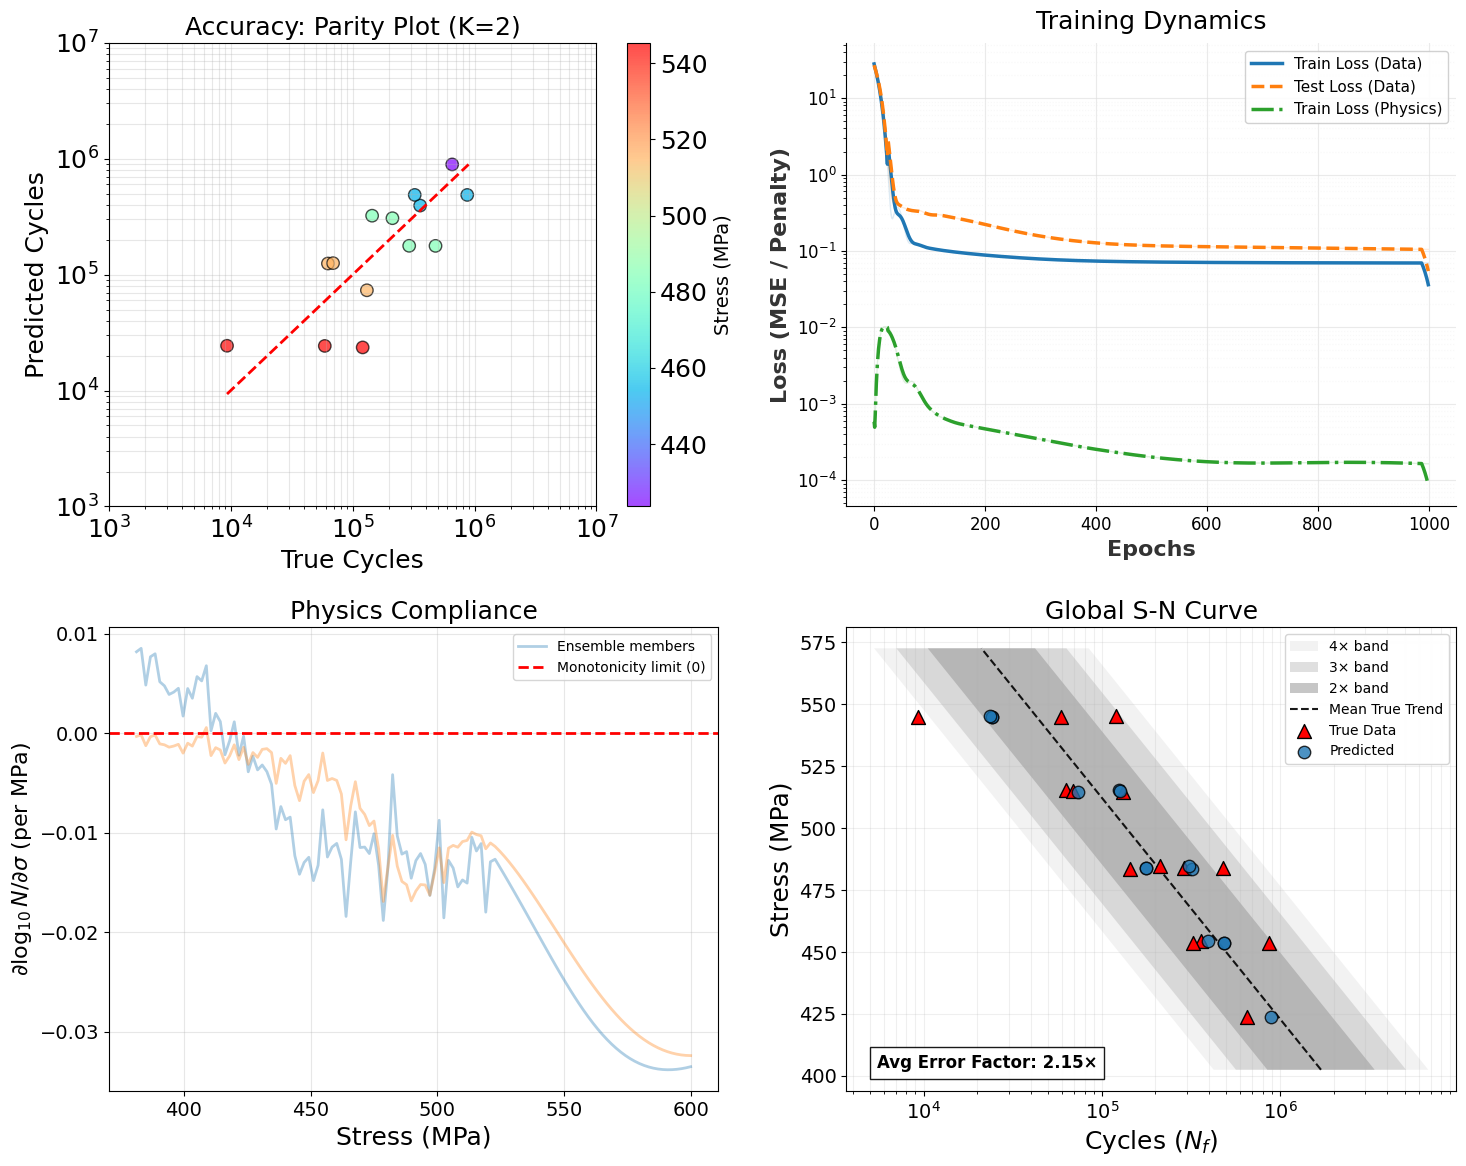

In [43]:
generate_final_report(df, ensemble_models, model_xgb,device=device,lam_phys=0.1)

In [ ]:
def plot_sn_curve_with_bands_vibrant(df, ensemble_models, xgb_model, device='cpu'):
   
    np.random.seed(42)
    k = len(ensemble_models)
    
    kf = KFold(n_splits=k, shuffle=True, random_state=42)
    all_true, all_pred, all_stress = [], [], []

    for fold_idx, (train_idx, test_idx) in enumerate(kf.split(df)):
        test_fold = df.iloc[test_idx].copy()
        
        if "Run Out" in test_fold.columns:
            test_fold = test_fold[test_fold["Run Out"] != "yes"].copy()
        
        if test_fold.empty: continue

        test_fold["Predicted Temperature"] = xgb_model.predict(test_fold[["Maximum stress"]])
        pack = ensemble_models[fold_idx]
        model, scaler = pack["model"], pack["scaler"]
        
        X_test = test_fold[["Maximum stress", "Predicted Temperature"]].values
        X_test_s = scaler.transform(X_test)
        X_test_t = torch.tensor(X_test_s, dtype=torch.float32, device=device)
        
        model.eval()
        with torch.no_grad():
            logN = model(X_test_t).cpu().numpy().flatten()
            
        all_true.extend(test_fold["Number of cycles"].values)
        all_pred.extend(10**logN)
        all_stress.extend(test_fold["Maximum stress"].values)

    np_true = np.array(all_true)
    np_pred = np.array(all_pred)
    np_stress = np.array(all_stress)

    regr = LinearRegression()
    # Log-Life vs Stress
    regr.fit(df[["Maximum stress"]].values, np.log10(df["Number of cycles"].values))
    
    # Smooth line for plotting
    smooth_stress = np.linspace(df["Maximum stress"].min()*0.85, df["Maximum stress"].max()*1.1, 100)
    trend_cycles_smooth = 10**regr.predict(smooth_stress.reshape(-1, 1))

    # --- 3. PLOTTING ---
    plt.figure(figsize=(10, 7))
    
    # Plot Bands
    factors = [4, 3, 2] 
    colors = ['#E0E0E0', '#C0C0C0', '#A0A0A0'] 
    alphas = [0.4, 0.5, 0.6]
    for factor, color, alpha in zip(factors, colors, alphas):
        plt.fill_betweenx(smooth_stress, trend_cycles_smooth/factor, trend_cycles_smooth*factor, 
                          color=color, alpha=alpha, edgecolor='none', label=f'{factor}x Factor')

    plt.plot(trend_cycles_smooth, smooth_stress, 'k--', alpha=0.8, label='Anchored Trend')

    # Scatter (Failures only)
    plt.scatter(np_true, np_stress, marker='o', color='red', s=80, label='True Data', zorder=10, linewidth=1.5, edgecolors="k")
    plt.scatter(np_pred, np_stress, marker='o', color='blue', s=60, label='Predicted', alpha=1.0, zorder=11, edgecolors='k', linewidth=0.5)

    # Metrics
    rmse_log = np.sqrt(np.mean((np.log10(np_true) - np.log10(np_pred))**2))
    avg_error_factor = 10**rmse_log

    # --- 4. FORMATTING ---
    plt.xscale('log')
    plt.xlim(1e2, 1e8) 
    plt.ylim(df["Maximum stress"].min()-20, df["Maximum stress"].max()+20)
    
    ax = plt.gca()

    plt.xlabel('Cycles ($N_f$)', fontsize=12, fontweight='bold')
    plt.ylabel('Stress (MPa)', fontsize=12, fontweight='bold')
    plt.title('Global S-N Curve with Grayscale Scatter Bandsa', fontsize=14, fontweight='bold')
    legend = plt.legend(loc='upper right', framealpha=1, facecolor='white', edgecolor='black', fontsize=10, shadow=True)
    frame = legend.get_frame()
    frame.set_linewidth(1.0)
    # Text Box
    plt.figtext(0.15, 0.15, 
                f"Avg Error Factor: {avg_error_factor:.2f}x", 
                bbox={'facecolor':'white', 'alpha':1.0, 'pad':6, 'edgecolor':'black', 'boxstyle':'round,pad=0.5'}, 
                fontsize=11, fontweight='bold')

    plt.grid(True, which="both", ls="-", alpha=0.2)
    plt.tight_layout()
    plt.show()

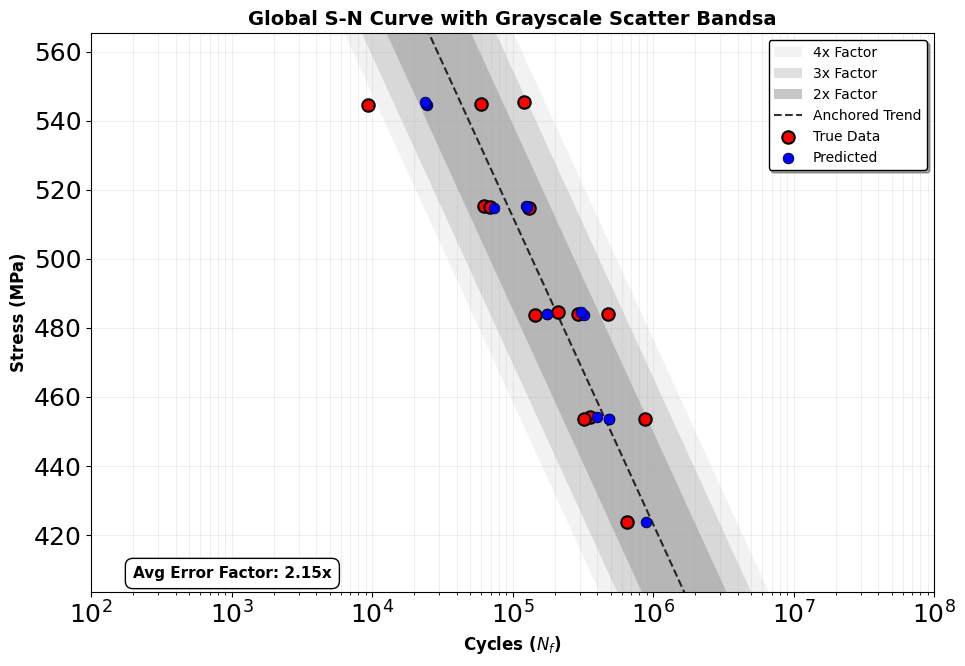

In [ ]:
plot_sn_curve_with_bands_vibrant(df, ensemble_models, model_xgb, device=device)

We try to implement and create a graph overlaying both models, one trained without the physics loss and another trained on physics loss

In [ ]:
def train_ghost_model(df, xgb_model, best_k):
    print("Training 'Ghost' Model (Physics Weight = 0.0)...")
    
    kf = KFold(n_splits=best_k, shuffle=True, random_state=42) 
    train_idx, test_idx = next(kf.split(df)) 
    
    train_fold = df.iloc[train_idx].copy()
    train_fold["Source"] = "real" 

    train_aug = augment_training_data(train_fold)
    
    if "Run Out" in train_aug.columns:
        train_aug = train_aug[train_aug["Run Out"] != "yes"].copy()

    train_aug["Predicted Temperature"] = xgb_model.predict(train_aug[["Maximum stress"]])
    
    X_train = train_aug[["Maximum stress", "Predicted Temperature"]].values
    y_train = train_aug["log cycles"].values.reshape(-1, 1)
    
    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train)
    X_tr_t = torch.tensor(X_train_s, dtype=torch.float32, device=device)
    y_tr_t = torch.tensor(y_train, dtype=torch.float32, device=device)
    
    model = LifeNet(hidden=64).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.002)
    
    model.train()
    for _ in range(1000):
        optimizer.zero_grad()
        pred = model(X_tr_t)
        loss = nn.MSELoss()(pred, y_tr_t) 
        loss.backward()
        optimizer.step()
        
    return {"model": model, "scaler": scaler}


ghost_package = train_ghost_model(df, model_xgb,best_k=2)

Training 'Ghost' Model (Physics Weight = 0.0)...
Standard Deviation (1 sigma): 5.46
95% Confidence Bound:        17.39
Actual noise within bound:   99.90%


Comparing Derivatives: PINN vs Ghost...


<Figure size 800x500 with 0 Axes>

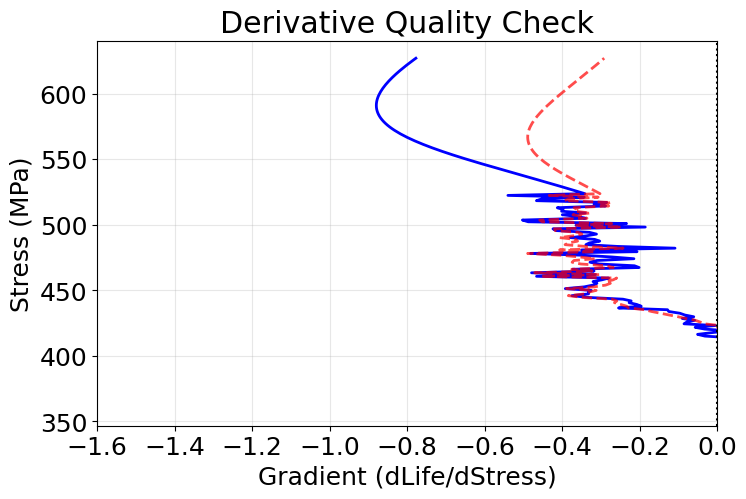

In [ ]:
def compare_model_derivatives(df, xgb_model, pinn_package, ghost_package, device):
    print("Comparing Derivatives: PINN vs Ghost...")
    
    min_stress = df["Maximum stress"].min() * 0.85
    max_stress = df["Maximum stress"].max() * 1.15
    
    stress_range = np.linspace(min_stress, max_stress, 200).reshape(-1, 1)
    temp_range = xgb_model.predict(stress_range).reshape(-1, 1)
    
    X_raw = np.column_stack([stress_range, temp_range])
    
    # 1. Get Derivatives for PINN (using Fold 1)
    model_p, scaler_p = pinn_package[0]["model"], pinn_package[0]["scaler"]
    X_s_p = scaler_p.transform(X_raw)
    X_t_p = torch.tensor(X_s_p, dtype=torch.float32, device=device, requires_grad=True)
    
    model_p.eval()
    pred_p = model_p(X_t_p)
    grads_p = torch.autograd.grad(pred_p, X_t_p, torch.ones_like(pred_p))[0]
    deriv_pinn = grads_p[:, 0].cpu().detach().numpy()
    
    # 2. Get Derivatives for Ghost
    model_g, scaler_g = ghost_package["model"], ghost_package["scaler"]
    X_s_g = scaler_g.transform(X_raw)
    X_t_g = torch.tensor(X_s_g, dtype=torch.float32, device=device, requires_grad=True)
    
    model_g.eval()
    pred_g = model_g(X_t_g)
    grads_g = torch.autograd.grad(pred_g, X_t_g, torch.ones_like(pred_g))[0]
    deriv_ghost = grads_g[:, 0].cpu().detach().numpy()
    
    # 4. Plot Comparison
    plt.figure(figsize=(8, 5))
    plt.figure(figsize=(8, 5))
    plt.plot(deriv_pinn, stress_range, 'b-', linewidth=2, label='PINN Derivative')
    plt.plot(deriv_ghost, stress_range, 'r--', linewidth=2, alpha=0.7, label='Ghost Derivative')
 
    plt.axvline(0, color='k', linestyle=':', label='Zero Line')
 
    plt.xlabel('Gradient (dLife/dStress)')
    plt.xlim(-1.6, 0)
    plt.ylabel('Stress (MPa)')
    plt.title('Derivative Quality Check')
    plt.grid(True, alpha=0.3)
    plt.show()
compare_model_derivatives(df,model_xgb, ensemble_models, ghost_package, device)

Running the No physics model to check how the predictions vary when we include the physics loss terms 

In [ ]:
def train_no_physics_model(df, xgb_model, k_folds=21):
    print(f"Training 'Pure Data' Model (Physics Weight = 0.0) using K={k_folds}...")
    
    kf = KFold(n_splits=k_folds, shuffle=True, random_state=42)
    train_idx, test_idx = next(kf.split(df))
    
    train_fold = df.iloc[train_idx].copy()
    train_fold["Source"] = "real" 

    train_aug = augment_training_data(train_fold)
    
    if "Run Out" in train_aug.columns:
        train_aug = train_aug[train_aug["Run Out"] != "yes"].copy()
    
    train_aug["Predicted Temperature"] = xgb_model.predict(train_aug[["Maximum stress"]])
    
    X_train = train_aug[["Maximum stress", "Predicted Temperature"]].values
    y_train = train_aug["log cycles"].values.reshape(-1, 1)
    
    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train)
    X_tr_t = torch.tensor(X_train_s, dtype=torch.float32, device=device)
    y_tr_t = torch.tensor(y_train, dtype=torch.float32, device=device)
    
    model = LifeNet(hidden=64).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.002)
    
    model.train()
    for _ in range(1000):
        optimizer.zero_grad()
        pred = model(X_tr_t)
        loss = nn.MSELoss()(pred, y_tr_t) 
        loss.backward()
        optimizer.step()
        
    return {"model": model, "scaler": scaler}

In [ ]:
def visualize_predictions_comparison(df, pinn_ensemble, no_phys_package, xgb_model, device='cpu'):
    print("Generating Prediction Overlay: PINN vs No-Physics...")
    
    pinn_model, pinn_scaler = pinn_ensemble[0]["model"], pinn_ensemble[0]["scaler"]
    np_model, np_scaler = no_phys_package["model"], no_phys_package["scaler"]
    
    # Setup Grid
    min_stress = df["Maximum stress"].min() 
    max_stress = df["Maximum stress"].max()
    stress_range = np.linspace(min_stress, max_stress, 200).reshape(-1, 1)
    
    # Predict Temps for the grid to keep it physical
    temp_pred = xgb_model.predict(pd.DataFrame(stress_range, columns=["Maximum stress"])).reshape(-1, 1)
    X_grid = np.column_stack([stress_range, temp_pred])
    
    # Predictions
    X_pinn_t = torch.tensor(pinn_scaler.transform(X_grid), dtype=torch.float32, device=device)
    X_np_t = torch.tensor(np_scaler.transform(X_grid), dtype=torch.float32, device=device)
    
    pinn_model.eval(); np_model.eval()
    with torch.no_grad():
        logN_pinn = pinn_model(X_pinn_t).cpu().numpy().flatten()
        logN_np = np_model(X_np_t).cpu().numpy().flatten()
        
    if "Run Out" in df.columns:
        df_failures = df[df["Run Out"] != "yes"]
    else:
        df_failures = df

    # --- PLOT ---
    plt.figure(figsize=(10, 7))
    
    # 1. Experimental Failures
    plt.scatter(df_failures["Number of cycles"], df_failures["Maximum stress"], 
                c='red', marker='o', s=100, edgecolors='k', label='Experimental (Failures)', zorder=10)
    
    # 2. PINN curve 
    plt.plot(10**logN_pinn, stress_range, 'b-', linewidth=3, label='PINN (Physics-Informed)', zorder=5)
    
    # 3. Standard NN 
    plt.plot(10**logN_np, stress_range, 'k--', linewidth=2, label='Standard NN (Data-Only)', alpha=0.7)
    
    plt.xscale('log')
    plt.xlabel('Cycles to Failure ($N_f$)', fontsize=14)
    plt.ylabel('Maximum Stress (MPa)', fontsize=14)
    plt.title('Prediction Comparison: Benefit of Physics Constraints', fontsize=16, fontweight='bold')
    
    # Format log ticks
    ax = plt.gca()
    ax.set_xticks([1e2, 1e3, 1e4, 1e5, 1e6, 1e7, 1e8])
    ax.set_xticklabels([r'$10^2$', r'$10^3$', r'$10^4$', r'$10^5$', r'$10^6$', r'$10^7$', r'$10^8$'])
    
    plt.legend(loc='best', frameon=True, shadow=True)
    plt.grid(True, which="both", alpha=0.2)
    plt.xlim(1e2, 1e8)
    plt.ylim(min_stress - 50, max_stress + 50)
    plt.tight_layout()
    plt.show()

The following scatter plot shows how the predictions look like. The jitters or wobbly line we see is from the temperature prediction, as we used the xgboost model to predict the temp for correspomdomg stress values. Number of cycles is highly sensitive to the temperature. And also, xgboost does not give a smooth curve, rather it gives a stepwise graph as we can observe from the plot as well

Global Random Seed set to: 21
Training 'Pure Data' Model (Physics Weight = 0.0) using K=2...
Standard Deviation (1 sigma): 5.46
95% Confidence Bound:        17.39
Actual noise within bound:   99.90%
Generating Prediction Overlay: PINN vs No-Physics...


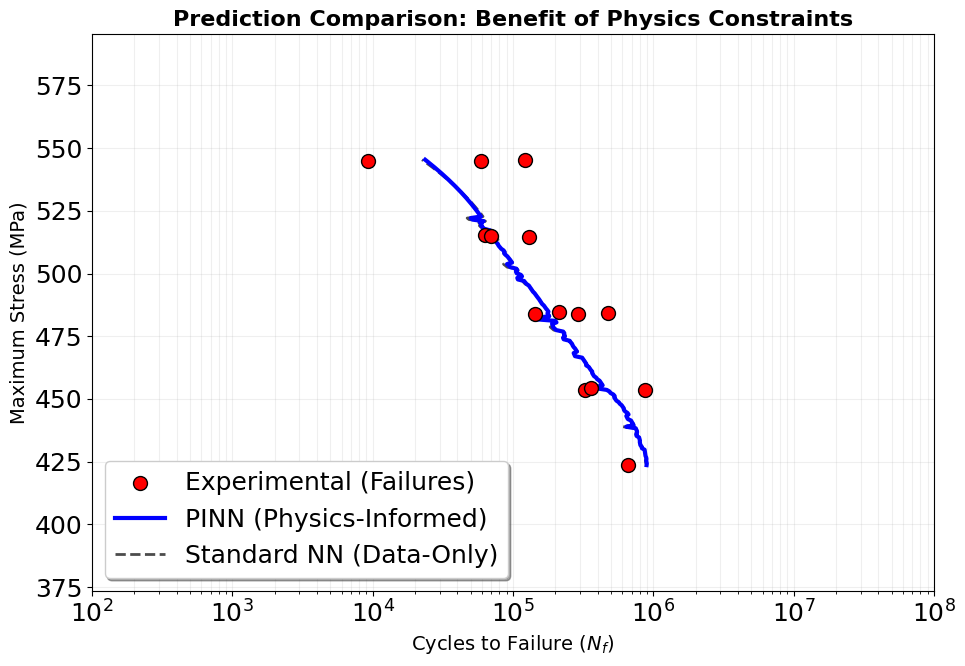

In [ ]:
# 1. Train the No physics model
set_seed(21)
no_phys_model = train_no_physics_model(df, model_xgb, k_folds=2)

# 2. Visualize the difference
visualize_predictions_comparison(df, ensemble_models, no_phys_model, model_xgb)

In [47]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.svm import SVR
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from xgboost import XGBRegressor

models = {
    "Random Forest": RandomForestRegressor(
        n_estimators=100,
        max_depth=5,
        random_state=42
    ),

    "SVR (RBF)": make_pipeline(
        StandardScaler(),
        SVR(C=10, epsilon=0.25, kernel='rbf')
    ),

    "SVR (RBF V2)": make_pipeline(
        StandardScaler(),
        SVR(C=1, epsilon=0.9, kernel='rbf')
    ),

    "SVR (POLY)": make_pipeline(
        StandardScaler(),
        SVR(C=1, epsilon=0.5, kernel='poly')
    ),

    "MLP": MLPRegressor(
        hidden_layer_sizes=(32,16),
        max_iter=2000,
        random_state=42
    ),

    "XGBoost": XGBRegressor(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    )
}

In [49]:
results = []

global_predictions = {}

from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

kf = KFold(n_splits=2, shuffle=True, random_state=42)

for model_name, model in models.items():

    all_true = []
    all_pred = []

    for fold, (train_idx, test_idx) in enumerate(kf.split(df)):

        train_df = df.iloc[train_idx].copy()
        test_df = df.iloc[test_idx].copy()

        # Temperature prediction
        train_df["Predicted Temperature"] = model_xgb.predict(
            train_df[["Maximum stress"]]
        )

        test_df["Predicted Temperature"] = model_xgb.predict(
            test_df[["Maximum stress"]]
        )

        X_train = train_df[[
            "Maximum stress",
            "Predicted Temperature"
        ]]

        X_test = test_df[[
            "Maximum stress",
            "Predicted Temperature"
        ]]

        y_train = train_df["log cycles"]
        y_test = test_df["log cycles"]

        # Train
        model.fit(X_train, y_train)

        # Predict
        preds = model.predict(X_test)

        # Store globally
        all_true.extend(y_test.values)
        all_pred.extend(preds)

    # Convert
    all_true = np.array(all_true)
    all_pred = np.array(all_pred)

    # GLOBAL metrics
    mse = mean_squared_error(all_true, all_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(all_true, all_pred)
    r2 = r2_score(all_true, all_pred)

    results.append({
        "Model": model_name,
        "MSE": mse,
        "RMSE": rmse,
        "MAE": mae,
        "R2": r2
    })

    global_predictions[model_name] = {
        "y_true": all_true,
        "y_pred": all_pred
    }

all_true_pinn = []
all_pred_pinn = []

kf = KFold(n_splits=2, shuffle=True, random_state=42)

for fold_idx, (train_idx, test_idx) in enumerate(kf.split(df)):

    test_fold = df.iloc[test_idx].copy()

    test_fold["Predicted Temperature"] = model_xgb.predict(
        test_fold[["Maximum stress"]]
    )

    pack = ensemble_models[fold_idx]

    model = pack["model"]
    scaler = pack["scaler"]

    X_test = test_fold[[
        "Maximum stress",
        "Predicted Temperature"
    ]].values

    X_test_s = scaler.transform(X_test)

    X_test_t = torch.tensor(
        X_test_s,
        dtype=torch.float32,
        device=device
    )

    model.eval()

    with torch.no_grad():
        preds = model(X_test_t).cpu().numpy().flatten()

    y_true = test_fold["log cycles"].values

    all_true_pinn.extend(y_true)
    all_pred_pinn.extend(preds)

# Convert
all_true_pinn = np.array(all_true_pinn)
all_pred_pinn = np.array(all_pred_pinn)

# GLOBAL PINN metrics
mse = mean_squared_error(all_true_pinn, all_pred_pinn)
rmse = np.sqrt(mse)
mae = mean_absolute_error(all_true_pinn, all_pred_pinn)
r2 = r2_score(all_true_pinn, all_pred_pinn)

results.append({
    "Model": "PINN",
    "MSE": mse,
    "RMSE": rmse,
    "MAE": mae,
    "R2": r2
})

global_predictions["PINN"] = {
    "y_true": all_true_pinn,
    "y_pred": all_pred_pinn
}

/Users/gauravsharma/miniconda3/lib/python3.12/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/gauravsharma/miniconda3/lib/python3.12/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/gauravsharma/miniconda3/lib/python3.12/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/gauravsharma/miniconda3/lib/python3.12/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/gauravsharma/miniconda3/lib/python3.12/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/gauravsharma/miniconda3/lib/python3.12/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/gauravsharma/miniconda3/lib/python3.12/site-packages/sklearn/util

In [50]:
results_df = pd.DataFrame(results)

results_df = results_df.round(4)

print(results_df)

           Model      MSE    RMSE     MAE       R2
0  Random Forest   0.1073  0.3276  0.2528   0.6014
1      SVR (RBF)   0.1542  0.3927  0.2660   0.4273
2   SVR (RBF V2)   0.3839  0.6196  0.4739  -0.4255
3     SVR (POLY)   0.1500  0.3874  0.2852   0.4428
4            MLP  12.1450  3.4850  3.3939 -44.1010
5        XGBoost   0.1274  0.3570  0.3020   0.5268
6           PINN   0.1069  0.3269  0.2888   0.6032


In [52]:
results_df.to_csv("Baseline_model_comparison_Jia.csv", index=False)